<a href="https://colab.research.google.com/github/miSSkSambo/-Just_for_Fun-/blob/main/402306874_Credit_Risk_ML_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# MACHINE LEARNING 600 ASSIGNMENT
# CREDIT RISK PREDICTION SYSTEM
# ============================================================
#
# Student Name: Katlego Sambo
# Student Number: 402306874
# Qualification: Articulation to BSC
# Year of Study: 2026
# Semester: Second semester
#
# Project:
# Credit Risk Prediction using Machine Learning and PCA
# ============================================================

# Credit Risk Prediction System

## Introduction

Financial institutions need effective ways to evaluate credit risk, as inaccurate lending choices can lead to financial losses or lost business prospects.


The initative creates a supervised machine learning driven credit risk forcasting system. The system employs a real world credit risk dataset to categorize loan applicants loan applicants based on risk level.


The project adheres to the machine learning life cycle, which encompasses data collection, exploratory data analysis, data cleansing, preprocessing, feature scaling, principal component analysis model creation, model assessment and hyperparameter tuning


Three classification methods will be assessed:

1. Logistic Regression
2. k-Nearest Neighbours
3. Decision Tree Classifier

The models will undergo evaluation priorr to and following PCA by means of accuracy, precision, recall, F1 score, confusion matrics and classification reports. The top performing model will subsequently be enhanced through hyperparameter tuning.

The ultimate outcomes will be analyzed from a commerical viewpoint, focusing specifically on false positives, false negatives, and the ramifications of erroneous credit risk choices

In [ ]:
# ============================================================
# LIBRARY IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import GridSearchCV

import warnings
warnings.filterwarnings("ignore")

# This random state ensures that the machine learning results
# can be reproduced when the notebook is run again.
RANDOM_STATE = 42

print("All required libraries have been imported successfully.")

All required libraries have been imported successfully.


In [ ]:
# ============================================================
# PART A: DATA ACQUISITION AND UNDERSTANDING
# ============================================================

# Load the Kaggle Credit Risk Dataset using Pandas.
#
# The CSV file was uploaded into the Google Colab environment.
# Pandas is used because it provides tools for loading,
# inspecting and analysing structured datasets.

df = pd.read_csv("credit_risk_dataset.csv")

print("Dataset loaded successfully!")
print()
print("First five records:")
display(df.head())

Dataset loaded successfully!

First five records:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
# ============================================================
# PART A: DATASET SHAPE
# ============================================================

# The shape of the dataset shows the number of observations
# and variables available for the credit-risk prediction task.

print("Dataset Shape:")
print(df.shape)

print("\nNumber of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset Shape:
(32581, 12)

Number of rows: 32581
Number of columns: 12


In [ ]:
# ============================================================
# PART A: DATASET COLUMNS
# ============================================================

# Display all variables contained in the dataset.
# These variables will later be separated into input features
# and the target variable.

print("Dataset Columns:")

for number, column in enumerate(df.columns, start=1):
    print(f"{number}. {column}")

Dataset Columns:
1. person_age
2. person_income
3. person_home_ownership
4. person_emp_length
5. loan_intent
6. loan_grade
7. loan_amnt
8. loan_int_rate
9. loan_status
10. loan_percent_income
11. cb_person_default_on_file
12. cb_person_cred_hist_length


In [ ]:
# ============================================================
# PART A: DATASET INFORMATION
# ============================================================

# The .info() method provides information about:
# - The number of records
# - Column names
# - Non-null values
# - Data types
#
# This information helps us identify numerical and categorical
# variables and determine whether missing values exist.

print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [ ]:
# ============================================================
# PART A: DESCRIPTIVE STATISTICS
# ============================================================

# Descriptive statistics provide an overview of the numerical
# characteristics of the credit-risk dataset.
#
# Statistics such as mean, standard deviation, minimum,
# maximum and quartiles help us understand the distribution
# of the numerical variables.

print("Descriptive Statistics:")

display(df.describe(include="all").T)

Descriptive Statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


In [ ]:
# ============================================================
# PART A: MISSING VALUE ANALYSIS
# ============================================================

# Calculate the number and percentage of missing values
# in each column.

missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

print("Missing Value Summary:")

display(missing_summary)

Missing Value Summary:


,Missing Values,Missing Percentage
person_age,0,0.000000
person_income,0,0.000000
person_home_ownership,0,0.000000
person_emp_length,895,2.747000
loan_intent,0,0.000000
loan_grade,0,0.000000
loan_amnt,0,0.000000
loan_int_rate,3116,9.563856
loan_status,0,0.000000
loan_percent_income,0,0.000000


In [ ]:
# ============================================================
# TARGET VARIABLE CHECK
# ============================================================

# loan_status is the target variable that we want the
# machine learning models to predict.
#
# 0 represents one loan-status class and 1 represents the
# other class in this dataset.

print("Target Variable: loan_status")
print("\nTarget Value Counts:")

display(df["loan_status"].value_counts())

print("\nTarget Value Percentages:")

display(
    df["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target Variable: loan_status

Target Value Counts:


,count
loan_status,
0,25473
1,7108



Target Value Percentages:


,proportion
loan_status,
0,78.18
1,21.82


### Interpretation of Target Variable

The objective variable is `loan_status`, which includes two categories, 0 and 1.
There are 25,473 observations (78.18%) in class 0 and 7,108 observations
(21.82%) in class 1.

The findings indicate that the target variable exhibits imbalance due to class 0 includes significantly more observations than class 1

This dispairty ought to should be taken into account during the creating and assessment of machine learning models

Relying solely on accuracy might not give a full understanding of how the model performs, this precision, recall f-score and the confusion matric will be taken into account as well.

Loan Status Distribution:


,count
loan_status,
0,25473
1,7108


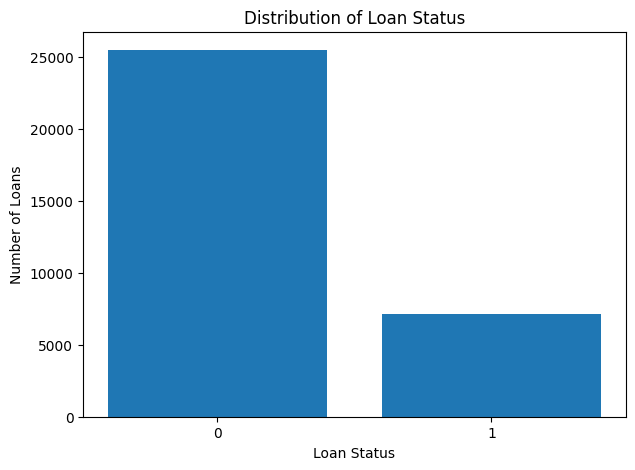

Loan Status Distribution:


,count
loan_status,
0,25473
1,7108


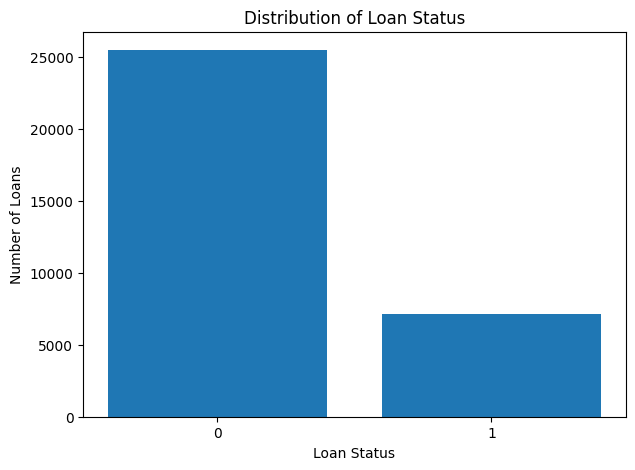

In [ ]:
# ============================================================
# PART B: EXPLORATORY DATA ANALYSIS
# ============================================================

# Analyse the distribution of the target variable.

import matplotlib.pyplot as plt

print("Loan Status Distribution:")

loan_status_counts = df["loan_status"].value_counts()

display(loan_status_counts)

# Create a bar chart
plt.figure(figsize=(7, 5))

plt.bar(
    loan_status_counts.index.astype(str),
    loan_status_counts.values
)

plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.title("Distribution of Loan Status")

plt.show()# ============================================================
# PART B: EXPLORATORY DATA ANALYSIS
# ============================================================

# Analyse the distribution of the target variable.

import matplotlib.pyplot as plt

print("Loan Status Distribution:")

loan_status_counts = df["loan_status"].value_counts()

display(loan_status_counts)

# Create a bar chart
plt.figure(figsize=(7, 5))

plt.bar(
    loan_status_counts.index.astype(str),
    loan_status_counts.values
)

plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.title("Distribution of Loan Status")

plt.show()

### Interpretation of Loan Status Distribution

The bar chart indicates that loan status 0 contains 25 473 obsetvations whereas loan status 1 comparises, 7108 observations. This indicates that the target variable is unevenly distributed with significantly more observations in class 0 compared to class 1.

This disparity is significant because a machine learning model might reach high accuracy by more often predicting the dominant class. Consquently, further evalution metrics like precision, recall, F1 score and the confusion matrix will be employed to enhance the assessment of model performance.

Home Ownership Distribution:


,count
person_home_ownership,
RENT,16446
MORTGAGE,13444
OWN,2584
OTHER,107


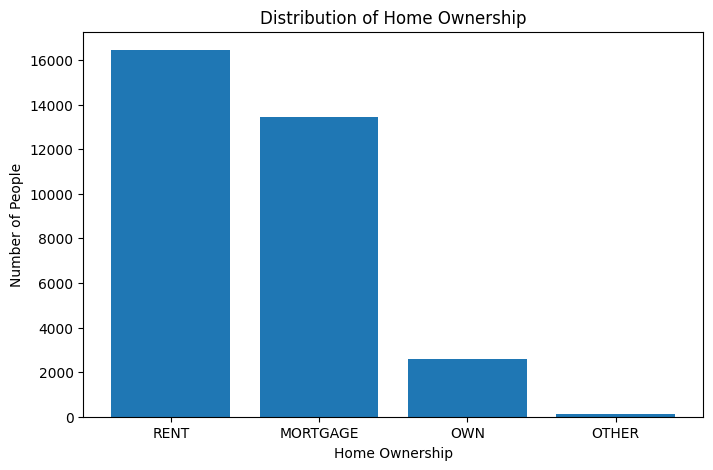

In [ ]:
# ============================================================
# EDA: HOME OWNERSHIP DISTRIBUTION
# ============================================================

print("Home Ownership Distribution:")

home_ownership_counts = df["person_home_ownership"].value_counts()

display(home_ownership_counts)

# Create a bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    home_ownership_counts.index,
    home_ownership_counts.values
)

plt.xlabel("Home Ownership")
plt.ylabel("Number of People")
plt.title("Distribution of Home Ownership")

plt.show()

### Interpretation of Home Ownership Distribution

The variable for home ownership illustrates how individuals are distributed based on their living situation. The classifications encompass various types of housing ownership like leasing, possessing a residence and having a loan.

The distribution aids in comprehending the traits of the individuals contained within the credit risk dataset. Variations in home ownership may also offer valuable insights when forecasting loan outcomes since financial situations can vary borrowers based on their housing circumstances

Loan Intent Distribution:


,count
loan_intent,
EDUCATION,6453
MEDICAL,6071
VENTURE,5719
PERSONAL,5521
DEBTCONSOLIDATION,5212
HOMEIMPROVEMENT,3605


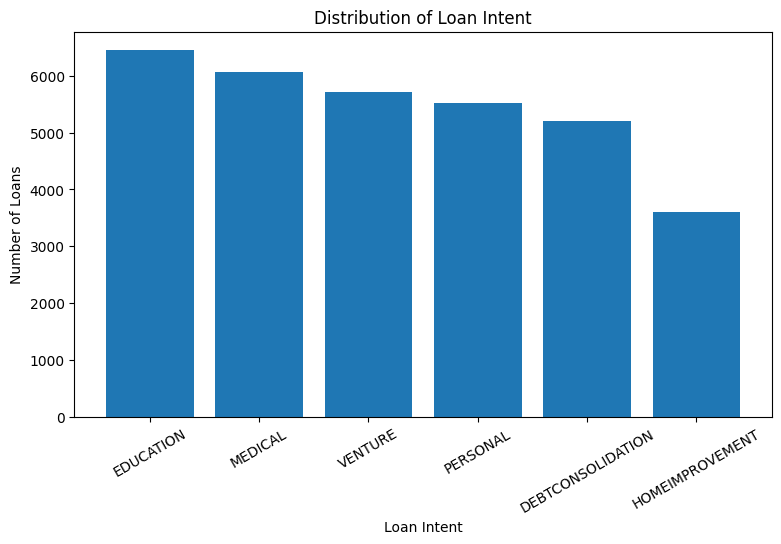

In [ ]:
# ============================================================
# EDA: LOAN INTENT DISTRIBUTION
# ============================================================

print("Loan Intent Distribution:")

loan_intent_counts = df["loan_intent"].value_counts()

display(loan_intent_counts)

# Create a bar chart
plt.figure(figsize=(9, 5))

plt.bar(
    loan_intent_counts.index,
    loan_intent_counts.values
)

plt.xlabel("Loan Intent")
plt.ylabel("Number of Loans")
plt.title("Distribution of Loan Intent")

plt.xticks(rotation=30)

plt.show()

### Interpretation of Loan Intent Distribution

The loan intent variable indicates the primary motivation behind why borrowers sought their debts. The bar chart illustrates the distribution of loan applications throughout the variious loan purpose categories.

The distribution shows that certain loan purposes can occur more frequently than others. Gasping the purpose of a loan is helpful in assessing credit risk forecasting assignment due to varying tyoes of borrowing potentially having distinct degrees of monetary risk.

This variable will be kept as one of the categorical inputs aspects when creating the machine learning models.

Loan Grade Distribution:


,count
loan_grade,
A,10777
B,10451
C,6458
D,3626
E,964
F,241
G,64


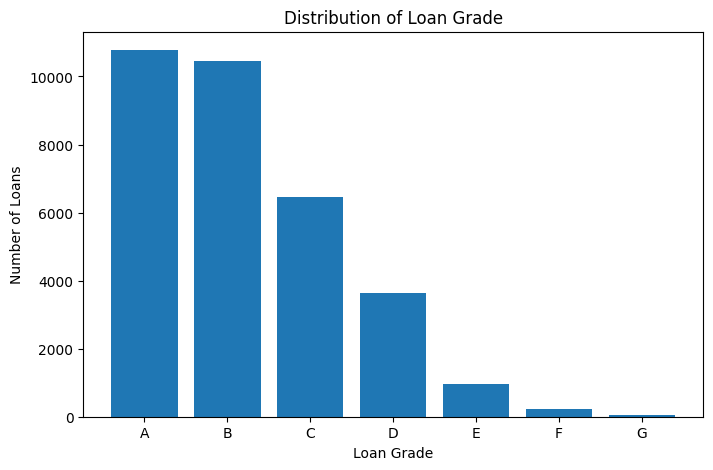

In [ ]:
# ============================================================
# EDA: LOAN GRADE DISTRIBUTION
# ============================================================

print("Loan Grade Distribution:")

loan_grade_counts = df["loan_grade"].value_counts().sort_index()

display(loan_grade_counts)

# Create a bar chart
plt.figure(figsize=(8, 5))

plt.bar(
    loan_grade_counts.index,
    loan_grade_counts.values
)

plt.xlabel("Loan Grade")
plt.ylabel("Number of Loans")
plt.title("Distribution of Loan Grade")

plt.show()

### Interpretation of Loan Grade Distribution

The loan grade variable denotes the classification given to every loan software. The dataset includes various categories of loan grades, spinning from loans of higher grades to loans of lower grades.


The bar chart indicates that the quanity that the quantity of loan applications is unevenly distributed spead out among all loan categories. Certain grades include significantly more observations than others.


Loan grade is significant categorical attribute for assessing credit risk forecasting assignment as it offers insights into the quality and risk degree linked to a loan request. As a result, this variable will be considered as an input variable during the creation of the machine learning models.

Previous Default History:


,count
cb_person_default_on_file,
N,26836
Y,5745


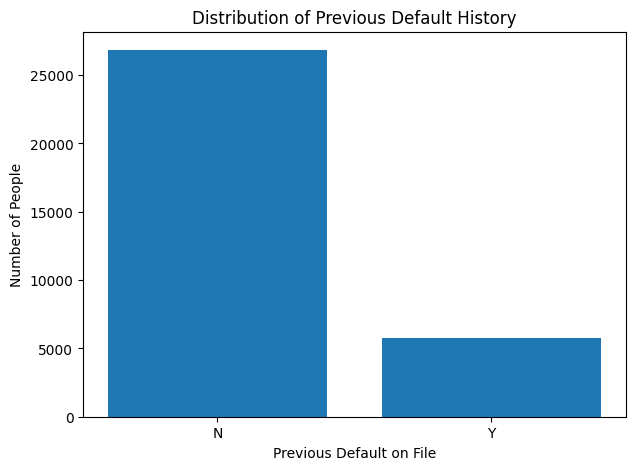

In [ ]:
# ============================================================
# EDA: PREVIOUS DEFAULT HISTORY
# ============================================================

print("Previous Default History:")

default_counts = df["cb_person_default_on_file"].value_counts()

display(default_counts)

# Create a bar chart
plt.figure(figsize=(7, 5))

plt.bar(
    default_counts.index,
    default_counts.values
)

plt.xlabel("Previous Default on File")
plt.ylabel("Number of People")
plt.title("Distribution of Previous Default History")

plt.show()

### Interpretation of Previous Default History

The `cb_person_default_on_file` variable shows if a borrower has a past default noted in their credit history.

The bar chart illustrates the spread of borrowers who have a prior default recorded versus those who do not. The findings offer insight into the credit backgrounds of the borrowers within the dataset.

Historical default data is signifcant for credit risk forecasting as prior default actions can offer valuable insights when evaluating the chances of future loan defualts. Consequently this variable willl be added as an input feature in the machine learning models

In [ ]:
# ============================================================
# EDA: NUMERICAL VARIABLE SUMMARY
# ============================================================

# Select the numerical variables used for exploratory analysis.

numerical_columns = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

print("Summary of Numerical Variables:")

display(df[numerical_columns].describe().T)

Summary of Numerical Variables:


,count,mean,std,min,25%,50%,75%,max
person_age,32581.0,27.734600,6.348078,20.00,23.00,26.00,30.00,144.00
person_income,32581.0,66074.848470,61983.119168,4000.00,38500.00,55000.00,79200.00,6000000.00
person_emp_length,31686.0,4.789686,4.142630,0.00,2.00,4.00,7.00,123.00
loan_amnt,32581.0,9589.371106,6322.086646,500.00,5000.00,8000.00,12200.00,35000.00
loan_int_rate,29465.0,11.011695,3.240459,5.42,7.90,10.99,13.47,23.22
loan_percent_income,32581.0,0.170203,0.106782,0.00,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,32581.0,5.804211,4.055001,2.00,3.00,4.00,8.00,30.00


### Interpretation of Numerical Variables

The summary statistics give a glimpse of the quantitve variables in the credit risk data set. The average and median figures offer insights into the usual traits of the borrowers and their loans, whereas the lowest and highest values indicate the span of observations

The standard deviation measures the extent to which the observations differ from their average values. Factors like earnings, loan size and interest rate could exhibit varying scales and degrees of fluctuation.

The summary additionally aids in recognizing potential outliners and disrepancies in the distributions of the numerical variables. These traits will be taken into account during the data preparation and machine learning phases.

In [ ]:
# ============================================================
# EDA: NUMERICAL MISSING VALUES
# ============================================================

print("Missing Values in Numerical Variables:")

numerical_missing = df[numerical_columns].isnull().sum()

display(numerical_missing)

Missing Values in Numerical Variables:


,0
person_age,0
person_income,0
person_emp_length,895
loan_amnt,0
loan_int_rate,3116
loan_percent_income,0
cb_person_cred_hist_length,0


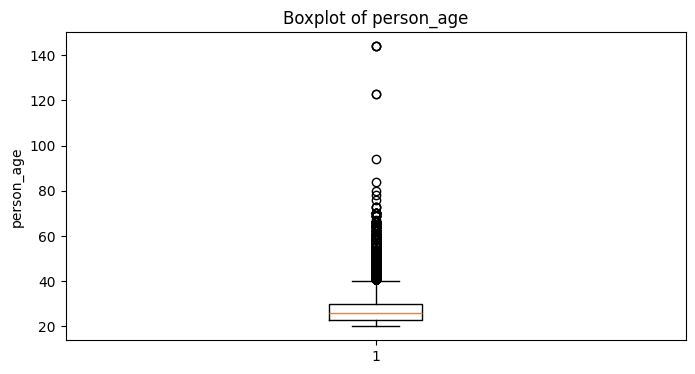

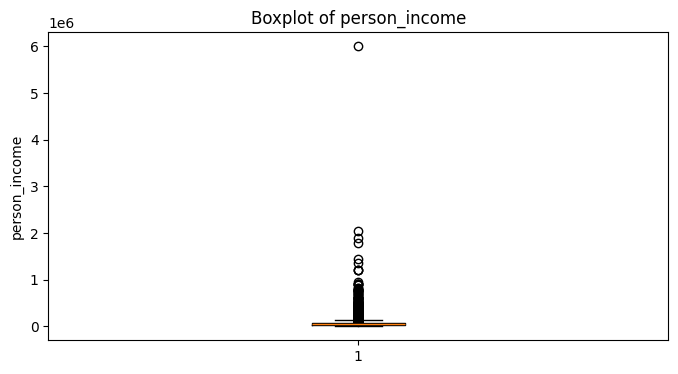

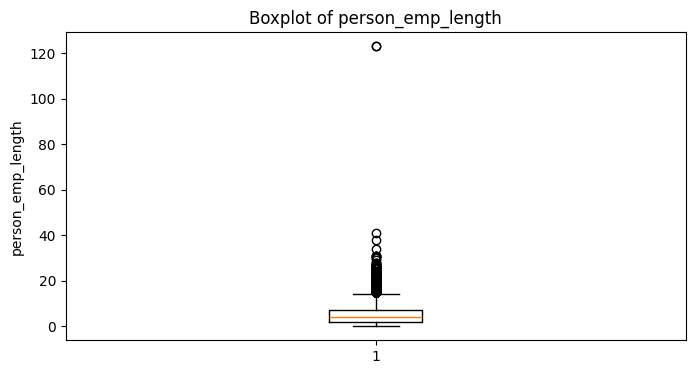

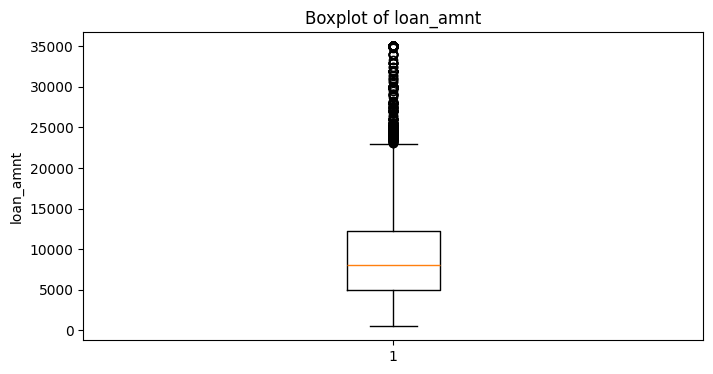

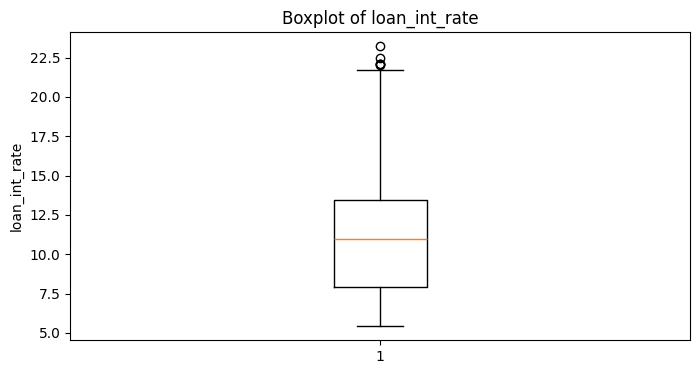

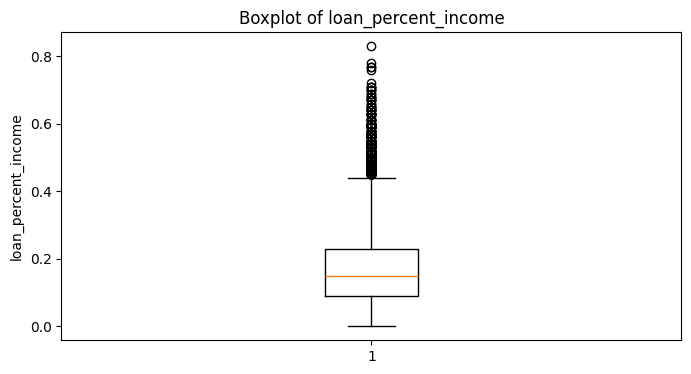

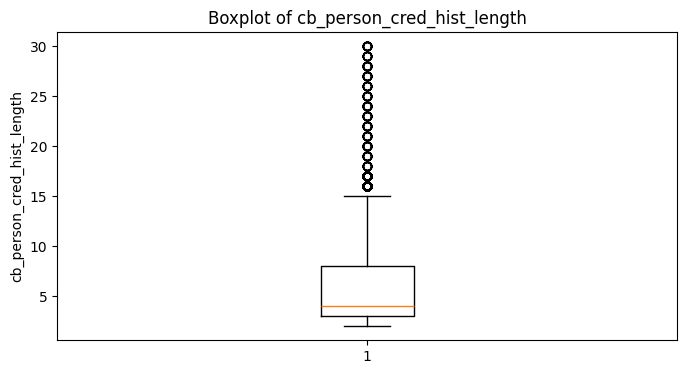

In [ ]:
# ============================================================
# EDA: BOXPLOTS FOR NUMERICAL VARIABLES
# ============================================================

for column in numerical_columns:

    plt.figure(figsize=(8, 4))

    plt.boxplot(df[column].dropna())

    plt.ylabel(column)
    plt.title(f"Boxplot of {column}")

    plt.show()

### Interpretation of Numerical Variable Boxplots

The boxplots offer a graphical depicction of the distribution and dispersion of the quantitive variables. They also assist in recognizing observations that might be possible anomalies.

Certain variables exhibit more variation compared to others. Especially monetary factors like income and loan amount might hold data points that are significantly above or below the central region of their distributions.

Possible outliners should not be discarded automatically as they could depict borrowers with distinctive financial traits. Their consequence will thus be taken itno account throughout the data preparation and modeling phases.

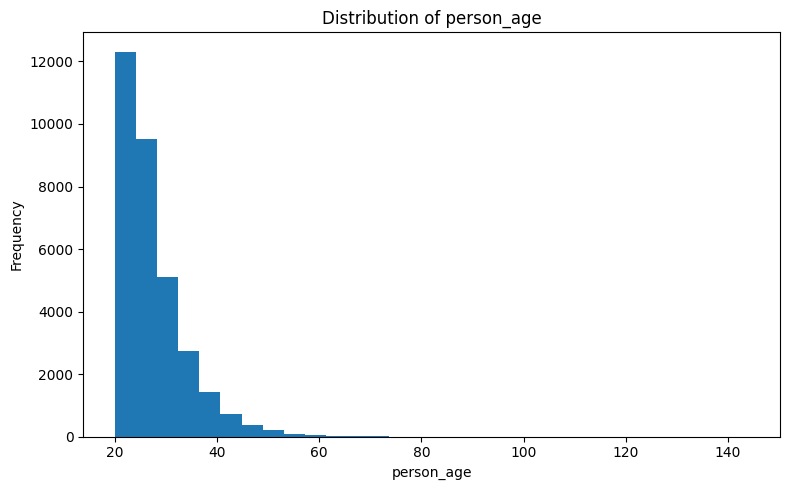

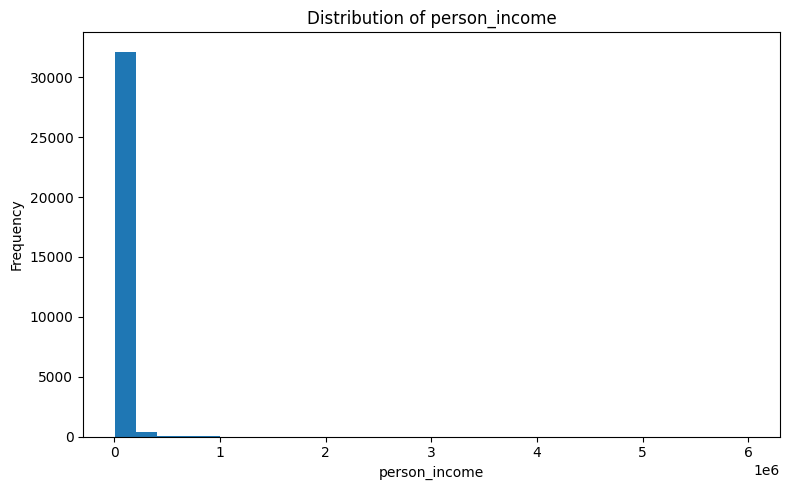

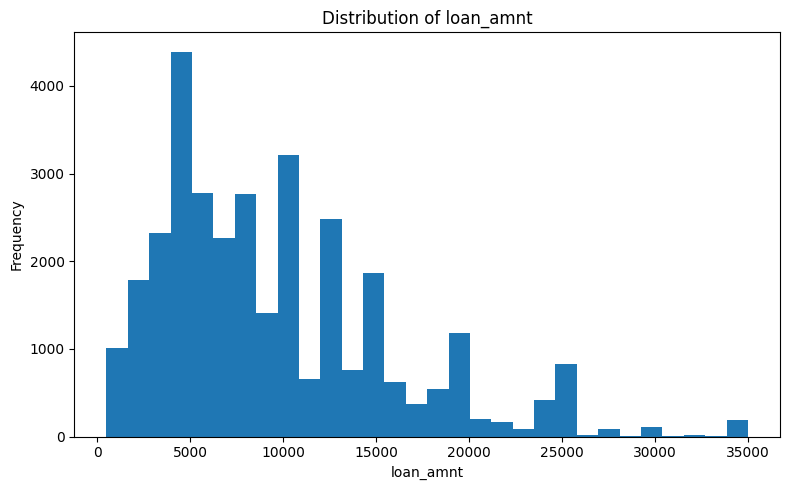

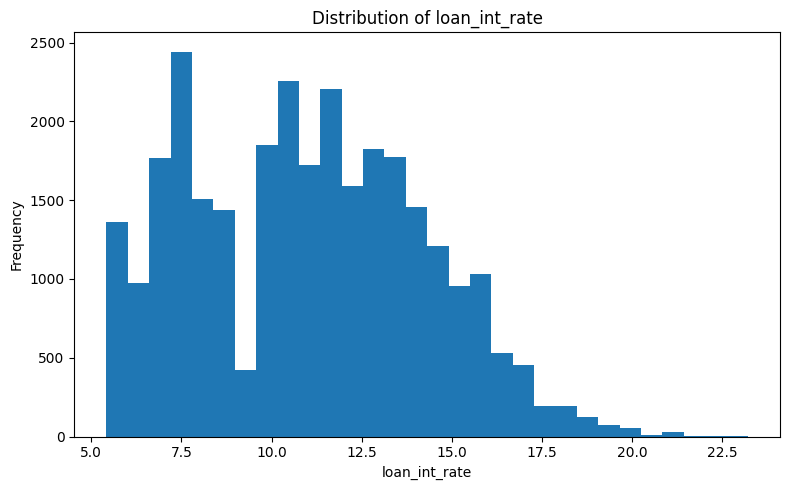

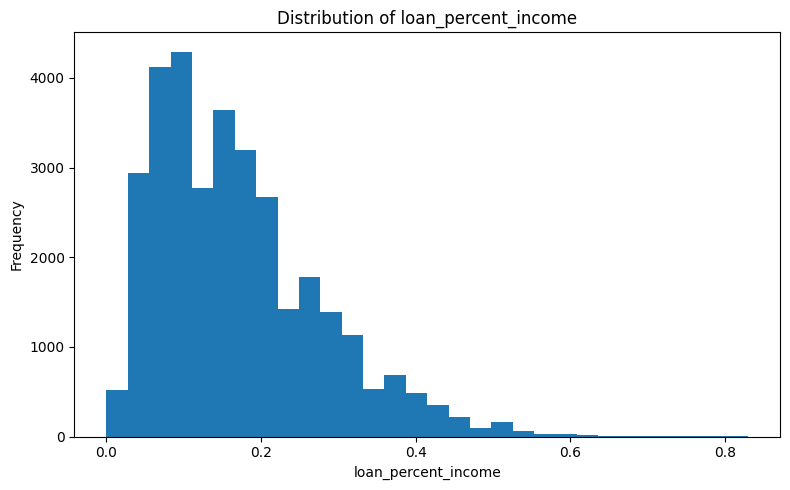

In [ ]:
# ============================================================
# PART B: HISTOGRAMS OF SELECTED NUMERICAL FEATURES
# ============================================================

# Histograms are used to examine the distribution of numerical
# variables. They help us identify the centre, spread, skewness
# and possible unusual values in the dataset.

selected_features = [
    "person_age",
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income"
]

for column in selected_features:

    plt.figure(figsize=(8, 5))

    plt.hist(
        df[column].dropna(),
        bins=30
    )

    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {column}")

    plt.tight_layout()
    plt.show()

    # Interpretation:
    # The histogram shows how the observations are distributed
    # across different values of the selected numerical feature.
    # The shape of each distribution can be examined for
    # concentration, skewness and unusual observations.

### Interpretation of Numerical Feature Histograms

The histograms display the distributions of chosen numerical variables in the credit risk data set.

The `person_age` histogram illustrates the age distribution of the applicants,
while `person_income` shows the distribution of annual income. The `loan_amnt`
histogram shows the distribution of loan amounts requested by applicants.

The `loan_int_rate` histogram shows the distribution of interest rates, and
`loan_percent_income` shows the proportion of an applicant's income
represented by the requested loan.

The histograms aids in recognizing variables that could be distorted or have abnormally high or low data pointgs. These traits will be taken into account at the preprocessing phase.

Correlation Matrix:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
person_age,1.000000,0.173202,0.163106,0.050787,0.012580,-0.021629,-0.042411,0.859133
person_income,0.173202,1.000000,0.134268,0.266820,0.000792,-0.144449,-0.254471,0.117987
person_emp_length,0.163106,0.134268,1.000000,0.113082,-0.056405,-0.082489,-0.054111,0.144699
loan_amnt,0.050787,0.266820,0.113082,1.000000,0.146813,0.105376,0.572612,0.041967
loan_int_rate,0.012580,0.000792,-0.056405,0.146813,1.000000,0.335133,0.120314,0.016696
loan_status,-0.021629,-0.144449,-0.082489,0.105376,0.335133,1.000000,0.379366,-0.015529
loan_percent_income,-0.042411,-0.254471,-0.054111,0.572612,0.120314,0.379366,1.000000,-0.031690
cb_person_cred_hist_length,0.859133,0.117987,0.144699,0.041967,0.016696,-0.015529,-0.031690,1.000000


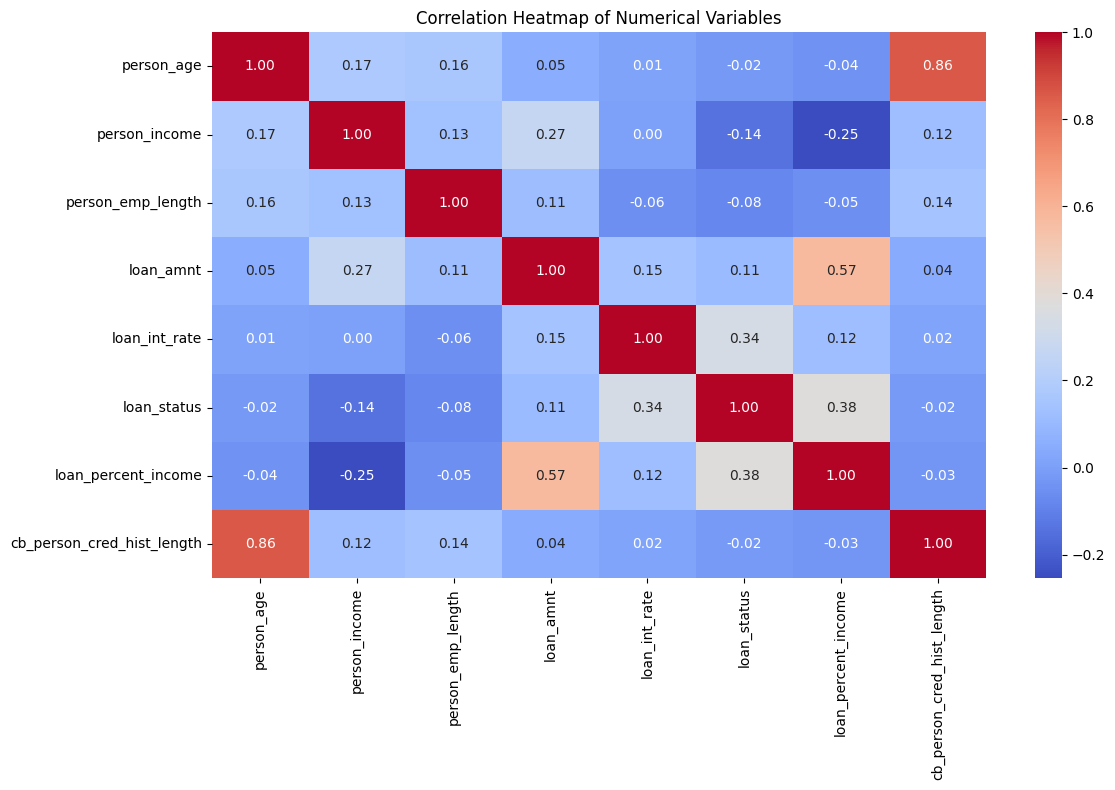

In [ ]:
# ============================================================
# PART B: CORRELATION HEATMAP
# ============================================================

# Select numerical variables for correlation analysis.

correlation_data = df.select_dtypes(include=np.number)

# Calculate the correlation matrix.

correlation_matrix = correlation_data.corr()

print("Correlation Matrix:")
display(correlation_matrix)

# Create the heatmap.

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()

plt.show()

# Interpretation:
# The heatmap displays the strength and direction of linear
# relationships between numerical variables.
#
# Values close to +1 indicate a strong positive relationship,
# values close to -1 indicate a strong negative relationship,
# and values close to 0 indicate a weak linear relationship.
#
# Examining correlations is useful because highly correlated
# features may contain overlapping information. This is also
# relevant to the later application of PCA.

### Interpretation of Correlation Heatmap

The correlation heatmap displays the connections among the numerical factors in the data collection. A positive correlation suggests that two variables often rise together, whereas negative correlation suggests that one the variable generally decreases when the other increases.

The correlation signifies the intensity of each relationship coefficient. Relationshipd approaching zero suggest weak linear correlations, whereas greater positive or negative values signify more intense relationships

The heatmap offers a summary of possible connections among the predictor variables and assists in recognizing variables that might hold intersecting data. This relates to PCA because PCA has the ability to transform related variables into a reduced set of main components.

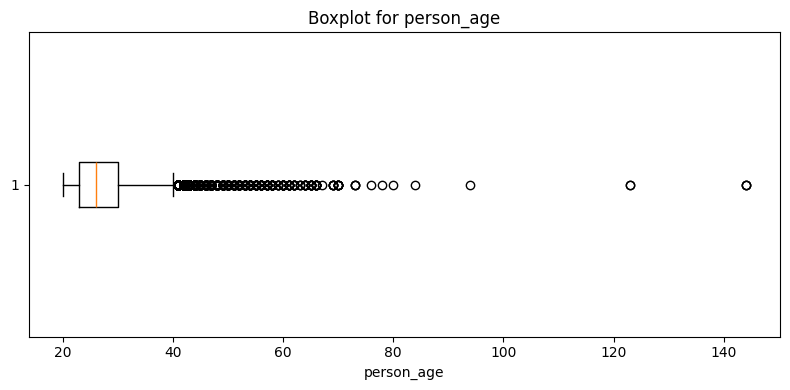

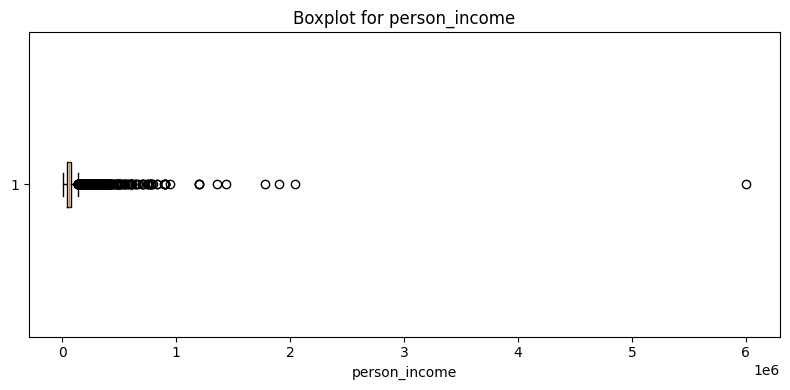

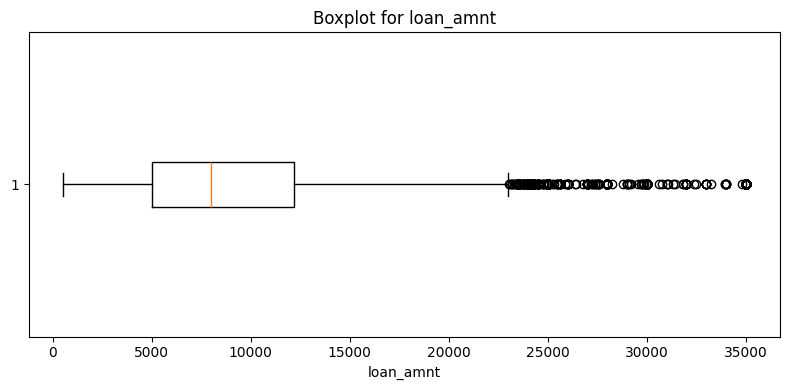

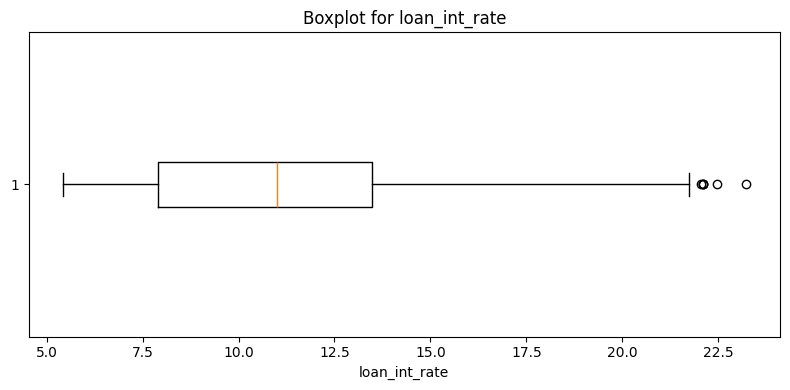

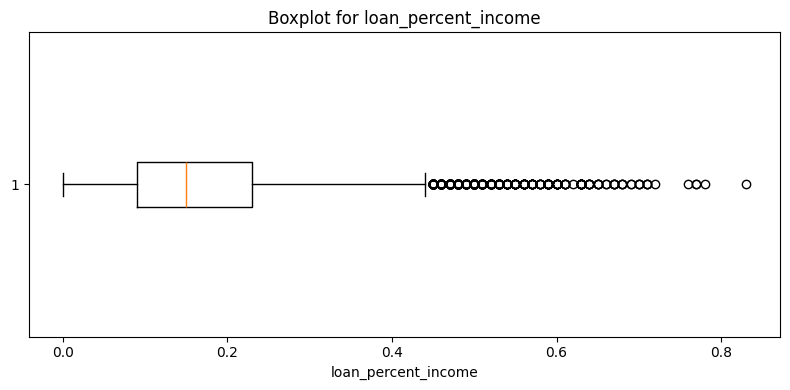

In [ ]:
# ============================================================
# PART B: BOXPLOTS FOR OUTLIER IDENTIFICATION
# ============================================================

# Boxplots are used to identify the spread of numerical data
# and potential observations that fall outside the typical
# range of the dataset.

for column in selected_features:

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        df[column].dropna(),
        vert=False
    )

    plt.xlabel(column)
    plt.title(f"Boxplot for {column}")

    plt.tight_layout()
    plt.show()

    # Interpretation:
    # Points or values beyond the whiskers may represent
    # potential outliers. These observations will be investigated
    # during preprocessing rather than automatically deleted.

### Interpretation of Boxplots and Potential Outliers

The boxplots give insights into the variation of the numerical variables and assist recognizing possible outliners. Observations outside the whiskers might indicate exeptionally high or low values

The existence of possible outliners does not inherently indicate that the observations are wrong. In a credit risk dataset, a typical income, age or loan amounts might reflect actual applicants.

Consequently possible outliners will be examined and hardled with caution during data preprocessing instead of being eliminated without reason

In [ ]:
# ============================================================
# PART C: DATA CLEANING AND PREPROCESSING
# STEP 1: CHECK FOR DUPLICATE RECORDS
# ============================================================

# Duplicate records can cause some observations to have
# excessive influence on a machine learning model.
#
# We first count the duplicate rows before removing them.

duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 165


In [ ]:
# ============================================================
# STEP 2: REMOVE DUPLICATE RECORDS
# ============================================================

# Duplicate rows are removed so that repeated observations
# do not unnecessarily influence the machine learning models.
#
# The index is reset after removing duplicates to maintain
# a clean sequential index.

df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate records after removal:", df.duplicated().sum())
print("Dataset shape after duplicate removal:", df.shape)

Duplicate records after removal: 0
Dataset shape after duplicate removal: (32416, 12)


In [ ]:
# ============================================================
# STEP 3: MISSING VALUE ANALYSIS BEFORE IMPUTATION
# ============================================================

# Display missing values again after duplicate removal.
# This confirms which variables require treatment before
# machine learning models are trained.

missing_before = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

display(missing_before)

,Missing Values,Missing Percentage
person_age,0,0.00
person_income,0,0.00
person_home_ownership,0,0.00
person_emp_length,887,2.74
loan_intent,0,0.00
loan_grade,0,0.00
loan_amnt,0,0.00
loan_int_rate,3095,9.55
loan_status,0,0.00
loan_percent_income,0,0.00


In [ ]:
# ============================================================
# STEP 4: SEPARATE FEATURES AND TARGET
# ============================================================

# loan_status is the target variable.
# All other columns are treated as predictor variables.

target = "loan_status"

X = df.drop(columns=[target])
y = df[target]

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

print("\nTarget variable:")
print(target)

print("\nTarget distribution:")
display(y.value_counts().sort_index())

Feature dataset shape: (32416, 11)
Target dataset shape: (32416,)

Target variable:
loan_status

Target distribution:


,count
loan_status,
0,25327
1,7089


In [ ]:
# ============================================================
# STEP 5: TRAIN-TEST SPLIT
# ============================================================

# The assignment requires an 80/20 training and testing split.
#
# The training set will be used to learn the preprocessing
# parameters and train the machine learning models.
#
# The testing set will remain unseen until model evaluation.
#
# Stratification maintains approximately the same target-class
# proportions in both the training and testing datasets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)
print("Training target  :", y_train.shape)
print("Testing target   :", y_test.shape)

Training features: (25932, 11)
Testing features : (6484, 11)
Training target  : (25932,)
Testing target   : (6484,)


In [ ]:
# ============================================================
# STEP 6: IDENTIFY FEATURE TYPES
# ============================================================

# Numerical variables will require missing-value treatment
# and feature scaling.
#
# Categorical variables will require missing-value treatment
# and encoding before they can be used by the models.

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numerical Features:")
for feature in numeric_features:
    print("-", feature)

print("\nCategorical Features:")
for feature in categorical_features:
    print("-", feature)

Numerical Features:
- person_age
- person_income
- person_emp_length
- loan_amnt
- loan_int_rate
- loan_percent_income
- cb_person_cred_hist_length

Categorical Features:
- person_home_ownership
- loan_intent
- loan_grade
- cb_person_default_on_file


In [ ]:
# ============================================================
# STEP 7: OUTLIER TREATMENT USING IQR CLIPPING
# ============================================================

# The Interquartile Range (IQR) is calculated from the training
# data for each numerical feature.
#
# Values below Q1 - 1.5(IQR) or above Q3 + 1.5(IQR) are treated
# as potential extreme values.
#
# Instead of deleting these observations, values outside the
# calculated boundaries are clipped to the boundary values.
# This preserves the observations while reducing the influence
# of extreme values.
#
# IMPORTANT:
# The boundaries are calculated using the training data only.
# This prevents information leakage from the test set.

X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

outlier_bounds = {}

for column in numeric_features:

    Q1 = X_train_clean[column].quantile(0.25)
    Q3 = X_train_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_bounds[column] = (
        lower_bound,
        upper_bound
    )

    X_train_clean[column] = X_train_clean[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    X_test_clean[column] = X_test_clean[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print("IQR-based outlier treatment completed.")

IQR-based outlier treatment completed.


In [ ]:
# ============================================================
# OUTLIER BOUNDARIES
# ============================================================

outlier_summary = pd.DataFrame(
    outlier_bounds,
    index=["Lower Bound", "Upper Bound"]
).T

display(outlier_summary)

,Lower Bound,Upper Bound
person_age,12.500,40.500
person_income,-21965.625,139009.375
person_emp_length,-5.500,14.500
loan_amnt,-5875.000,23125.000
loan_int_rate,-0.470,21.850
loan_percent_income,-0.120,0.440
cb_person_cred_hist_length,-4.500,15.500


In [ ]:
# ============================================================
# STEP 8: PREPROCESSING PIPELINE
# ============================================================

# Numerical preprocessing:
# 1. Missing numerical values are replaced using the median.
# 2. StandardScaler places numerical features on comparable
#    scales.
#
# Median imputation is used because the median is less sensitive
# to extreme values than the mean.

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing:
# 1. Missing categorical values are replaced by the most
#    frequently occurring category.
# 2. One-hot encoding converts categorical variables into
#    numerical variables that machine learning algorithms
#    can process.

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

# Combine the numerical and categorical preprocessing.

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [ ]:
# ============================================================
# STEP 9: APPLY PREPROCESSING
# ============================================================

# The preprocessing pipeline is fitted ONLY on the training
# data. This prevents information from the testing data from
# influencing the preprocessing parameters.
#
# The already-fitted preprocessing pipeline is then applied
# to the testing data.

X_train_processed = preprocessor.fit_transform(
    X_train_clean
)

X_test_processed = preprocessor.transform(
    X_test_clean
)

print("Preprocessing completed.")
print()
print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape :", X_test_processed.shape)

Preprocessing completed.

Processed training data shape: (25932, 26)
Processed testing data shape : (6484, 26)


In [ ]:
# ============================================================
# STEP 10: VERIFY PREPROCESSING
# ============================================================

# After imputation, the processed dataset should contain
# no missing values.

print("Missing values before preprocessing:")
print(X_train_clean.isnull().sum())

print("\nPreprocessing verification completed.")
print("The imputation stage has been applied to the numerical")
print("and categorical variables.")

Missing values before preprocessing:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              727
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 2488
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Preprocessing verification completed.
The imputation stage has been applied to the numerical
and categorical variables.


### Preprocessing Justification

The dataset was initally examined for duplicate entries and identical records. Data points were eliminated to avoid duplicate entries from having an unwanted impact on the models.

The missing values were addressed through median imputation. The midpoint was chosen because it is less affected by extreme vakues than the average. Absent categorical values were substituted with the mmost common happening type.

Numerical outliners were addrressed throough IQR based clipping. The aim was to dimish the impact of outliners without automatically removing possibly legimate canidates.

Categorical variables were transformed into numerical formats utilizng one hot encoding since the chosen machine learning algorithms demand numerical data.

Numerical features were normalized using StandardScaler. Normalization of features is especially crucial for algorithms like logistic regression and K-nearest neighbouts as variables with greater numerical ranges might alternatively extert an imbalanced impact on the model.

The dataset was split into 80% for training and 20% for testing. Parameters for preprocessing were derived from the training data and subsequently utilized on the testing data to minimize the chances of data leakage.

In [ ]:
# ============================================================
# PART D: PRINCIPAL COMPONENT ANALYSIS (PCA)
# STEP 1: APPLY PCA TO THE PROCESSED DATA
# ============================================================

# PCA is used to transform the processed features into a
# smaller set of principal components.
#
# The principal components are linear combinations of the
# original features and are ordered according to the amount
# of variance they explain.
#
# PCA is applied after preprocessing because the numerical
# variables have already been scaled and the categorical
# variables have been encoded.

pca_full = PCA()

X_train_pca_full = pca_full.fit_transform(
    X_train_processed
)

X_test_pca_full = pca_full.transform(
    X_test_processed
)

print("PCA successfully applied.")
print()
print("Original processed training shape:",
      X_train_processed.shape)

print("PCA training shape:",
      X_train_pca_full.shape)

print()
print("Original processed testing shape:",
      X_test_processed.shape)

print("PCA testing shape:",
      X_test_pca_full.shape)

PCA successfully applied.

Original processed training shape: (25932, 26)
PCA training shape: (25932, 26)

Original processed testing shape: (6484, 26)
PCA testing shape: (6484, 26)


In [ ]:
# ============================================================
# STEP 2: EXPLAINED VARIANCE RATIO
# ============================================================

# explained_variance_ratio_ shows the proportion of the total
# variance explained by each principal component.

explained_variance = (
    pca_full.explained_variance_ratio_
)

variance_table = pd.DataFrame({
    "Principal Component": range(
        1,
        len(explained_variance) + 1
    ),
    "Explained Variance Ratio": explained_variance
})

variance_table["Explained Variance (%)"] = (
    variance_table["Explained Variance Ratio"] * 100
).round(4)

print("Explained Variance Ratio:")
display(variance_table)

Explained Variance Ratio:


,Principal Component,Explained Variance Ratio,Explained Variance (%)
0,1,2.141075e-01,21.4107
1,2,1.789260e-01,17.8926
2,3,1.522362e-01,15.2236
3,4,1.250705e-01,12.5071
4,5,9.109983e-02,9.1100
5,6,3.975054e-02,3.9751
6,7,3.631479e-02,3.6315
7,8,2.042639e-02,2.0426
8,9,1.943766e-02,1.9438
9,10,1.860347e-02,1.8603


In [ ]:
# ============================================================
# STEP 3: CUMULATIVE EXPLAINED VARIANCE
# ============================================================

# Cumulative variance shows how much total variance is
# retained as additional principal components are included.

cumulative_variance = np.cumsum(
    explained_variance
)

cumulative_variance_table = pd.DataFrame({
    "Principal Component": range(
        1,
        len(cumulative_variance) + 1
    ),
    "Cumulative Variance Ratio": cumulative_variance
})

cumulative_variance_table[
    "Cumulative Variance (%)"
] = (
    cumulative_variance_table[
        "Cumulative Variance Ratio"
    ] * 100
).round(4)

print("Cumulative Explained Variance:")
display(cumulative_variance_table)

Cumulative Explained Variance:


,Principal Component,Cumulative Variance Ratio,Cumulative Variance (%)
0,1,0.214107,21.4107
1,2,0.393033,39.3033
2,3,0.545270,54.5270
3,4,0.670340,67.0340
4,5,0.761440,76.1440
5,6,0.801191,80.1191
6,7,0.837505,83.7505
7,8,0.857932,85.7932
8,9,0.877369,87.7369
9,10,0.895973,89.5973


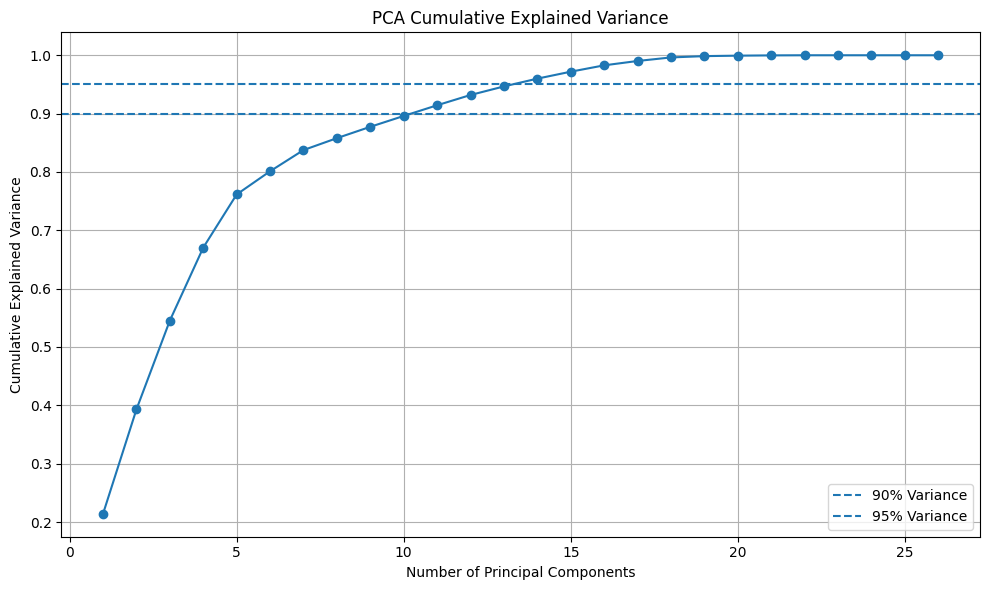

In [ ]:
# ============================================================
# STEP 4: PCA CUMULATIVE VARIANCE PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% Variance"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Interpretation:
# The cumulative variance plot shows how much of the
# information/variance in the original processed dataset
# is retained as more principal components are included.
#
# The 90% and 95% reference lines help identify how many
# components are required to retain most of the variance.

In [ ]:
# ============================================================
# STEP 5: COMPONENT SELECTION
# ============================================================

# Determine the minimum number of components required to
# capture at least 90% and 95% of the variance.

n_components_90 = (
    np.argmax(
        cumulative_variance >= 0.90
    ) + 1
)

n_components_95 = (
    np.argmax(
        cumulative_variance >= 0.95
    ) + 1
)

print(
    "Components required for at least 90% variance:",
    n_components_90
)

print(
    "Components required for at least 95% variance:",
    n_components_95
)

Components required for at least 90% variance: 11
Components required for at least 95% variance: 14


In [ ]:
# ============================================================
# STEP 6: CREATE FINAL PCA DATASET
# ============================================================

# We select the number of components required to retain at
# least 95% of the variance.
#
# The PCA model is fitted only on the training data.
# The same transformation is then applied to the testing data.

selected_components = n_components_95

pca = PCA(
    n_components=selected_components
)

X_train_pca = pca.fit_transform(
    X_train_processed
)

X_test_pca = pca.transform(
    X_test_processed
)

print("Selected number of PCA components:",
      selected_components)

print()
print("Original processed training shape:",
      X_train_processed.shape)

print("PCA training shape:",
      X_train_pca.shape)

print()
print("Original processed testing shape:",
      X_test_processed.shape)

print("PCA testing shape:",
      X_test_pca.shape)

Selected number of PCA components: 14

Original processed training shape: (25932, 26)
PCA training shape: (25932, 14)

Original processed testing shape: (6484, 26)
PCA testing shape: (6484, 14)


In [ ]:
# ============================================================
# STEP 7: VERIFY PCA VARIANCE RETENTION
# ============================================================

retained_variance = (
    pca.explained_variance_ratio_.sum()
)

print(
    "Number of selected components:",
    selected_components
)

print(
    "Total variance retained:",
    round(retained_variance * 100, 2),
    "%"
)

Number of selected components: 14
Total variance retained: 95.99 %


### PCA Interpretation

Principal component analysis was applied to the normalized and encoded training data to reduce dimensionality.

The explained variance ration reflects the share of overall variance accounted for by each principal component, whereas cumlative explained variance represents the total variance preserved with the inclusion of extra components.

Variance thresholds of 90% and 95% were assessed. The final PCA model perserves a minimum of 95% variance, cutting down features while keeping information intact. The PCA transformation is fitted solely on training data and subsequently applied to testing data to prevent any influence.

In [ ]:
# ============================================================
# RANDOM STATE
# ============================================================
#
# RANDOM_STATE ensures that operations involving randomness
# produce reproducible results when the notebook is rerun.
# ============================================================

RANDOM_STATE = 42

print("RANDOM_STATE has been set to:", RANDOM_STATE)

RANDOM_STATE has been set to: 42


In [ ]:
# ============================================================
# PART E: MODEL DEVELOPMENT AND EVALUATION
# ============================================================
#
# Three classification algorithms are required:
# 1. Logistic Regression
# 2. k-Nearest Neighbours (kNN)
# 3. Decision Tree
#
# These models will be evaluated using:
# Accuracy, Precision, Recall, F1-score,
# Confusion Matrix and Classification Report.
# ============================================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "k-Nearest Neighbours": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    )
}

print("Three required machine learning models have been created:")
for model_name in models:
    print("-", model_name)

Three required machine learning models have been created:
- Logistic Regression
- k-Nearest Neighbours
- Decision Tree


In [ ]:
# ============================================================
# PART E - REQUIRED IMPORTS
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Part E libraries imported successfully.")

Part E libraries imported successfully.


In [ ]:
# ============================================================
# MODEL EVALUATION FUNCTION
# ============================================================
#
# The evaluation function calculates several performance
# measures because accuracy alone may be misleading when
# the target classes are imbalanced.
#
# Precision measures how many observations predicted as
# positive were actually positive.
#
# Recall measures how many of the actual positive observations
# were correctly identified.
#
# F1-score provides a balance between precision and recall.
#
# The confusion matrix shows:
# True Positives, True Negatives,
# False Positives and False Negatives.
# ============================================================

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # Display results
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # Store results
    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    }


print("Model evaluation function created successfully.")

Model evaluation function created successfully.


In [ ]:
# ============================================================
# LOAD CREDIT RISK DATASET AGAIN
# ============================================================

import pandas as pd

df = pd.read_csv("credit_risk_dataset.csv")

print("Credit Risk Dataset loaded successfully!")
print()
print("Dataset shape:", df.shape)
print()
print("First five records:")
display(df.head())

Credit Risk Dataset loaded successfully!

Dataset shape: (32581, 12)

First five records:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [ ]:
# ============================================================
# RESTORE PART C PREPROCESSING
# ============================================================

# Required libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Reproducibility
RANDOM_STATE = 42

# ------------------------------------------------------------
# 1. Remove duplicate records
# ------------------------------------------------------------

df = df.drop_duplicates().reset_index(drop=True)

# ------------------------------------------------------------
# 2. Separate features and target
# ------------------------------------------------------------

target = "loan_status"

X = df.drop(columns=[target])
y = df[target]

# ------------------------------------------------------------
# 3. 80/20 Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# ------------------------------------------------------------
# 4. Identify numerical and categorical features
# ------------------------------------------------------------

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# ------------------------------------------------------------
# 5. Treat numerical outliers using IQR
# ------------------------------------------------------------

X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

for column in numeric_features:

    Q1 = X_train_clean[column].quantile(0.25)
    Q3 = X_train_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    X_train_clean[column] = X_train_clean[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

    X_test_clean[column] = X_test_clean[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

# ------------------------------------------------------------
# 6. Numerical preprocessing
# ------------------------------------------------------------

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# ------------------------------------------------------------
# 7. Categorical preprocessing
# ------------------------------------------------------------

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ]
)

# ------------------------------------------------------------
# 8. Combine preprocessing
# ------------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# ------------------------------------------------------------
# 9. Fit on training data and transform both datasets
# ------------------------------------------------------------

X_train_processed = preprocessor.fit_transform(X_train_clean)

X_test_processed = preprocessor.transform(X_test_clean)

# ------------------------------------------------------------
# 10. Verification
# ------------------------------------------------------------

print("PART C PREPROCESSING RESTORED SUCCESSFULLY!")
print()
print("Original dataset shape:", df.shape)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print()
print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)
print()
print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

PART C PREPROCESSING RESTORED SUCCESSFULLY!

Original dataset shape: (32416, 12)
Training data shape: (25932, 11)
Testing data shape: (6484, 11)

Processed training data shape: (25932, 26)
Processed testing data shape: (6484, 26)

Numerical features: 7
Categorical features: 4


In [ ]:
# ============================================================
# PART D - PRINCIPAL COMPONENT ANALYSIS (PCA)
# ============================================================
#
# PCA is applied to the processed and scaled features.
# First, we create a full PCA model so that we can examine
# how much variance is explained by each component.
# ============================================================

pca_full = PCA()

# Fit PCA using training data only
X_train_pca_full = pca_full.fit_transform(X_train_processed)

# Apply the same PCA transformation to testing data
X_test_pca_full = pca_full.transform(X_test_processed)

print("PCA successfully applied!")
print()
print("Original processed training shape:", X_train_processed.shape)
print("PCA training shape:", X_train_pca_full.shape)
print()
print("Original processed testing shape:", X_test_processed.shape)
print("PCA testing shape:", X_test_pca_full.shape)

PCA successfully applied!

Original processed training shape: (25932, 26)
PCA training shape: (25932, 26)

Original processed testing shape: (6484, 26)
PCA testing shape: (6484, 26)


In [ ]:
# ============================================================
# PART D - EXPLAINED VARIANCE RATIO
# ============================================================

# Get the variance explained by each principal component
explained_variance = pca_full.explained_variance_ratio_

# Create a table showing the variance explained
variance_table = pd.DataFrame({
    "Principal Component": range(
        1,
        len(explained_variance) + 1
    ),
    "Explained Variance Ratio": explained_variance
})

variance_table["Explained Variance (%)"] = (
    variance_table["Explained Variance Ratio"] * 100
).round(4)

print("Explained Variance by Principal Component:")
display(variance_table)

Explained Variance by Principal Component:


,Principal Component,Explained Variance Ratio,Explained Variance (%)
0,1,2.141075e-01,21.4107
1,2,1.789260e-01,17.8926
2,3,1.522362e-01,15.2236
3,4,1.250705e-01,12.5071
4,5,9.109983e-02,9.1100
5,6,3.975054e-02,3.9751
6,7,3.631479e-02,3.6315
7,8,2.042639e-02,2.0426
8,9,1.943766e-02,1.9438
9,10,1.860347e-02,1.8603


In [ ]:
# ============================================================
# PART D - CUMULATIVE EXPLAINED VARIANCE
# ============================================================

# Calculate cumulative variance
cumulative_variance = np.cumsum(explained_variance)

# Create a table
cumulative_variance_table = pd.DataFrame({
    "Principal Component": range(
        1,
        len(cumulative_variance) + 1
    ),
    "Cumulative Variance Ratio": cumulative_variance
})

cumulative_variance_table["Cumulative Variance (%)"] = (
    cumulative_variance_table["Cumulative Variance Ratio"] * 100
).round(4)

print("Cumulative Explained Variance:")
display(cumulative_variance_table)

Cumulative Explained Variance:


,Principal Component,Cumulative Variance Ratio,Cumulative Variance (%)
0,1,0.214107,21.4107
1,2,0.393033,39.3033
2,3,0.545270,54.5270
3,4,0.670340,67.0340
4,5,0.761440,76.1440
5,6,0.801191,80.1191
6,7,0.837505,83.7505
7,8,0.857932,85.7932
8,9,0.877369,87.7369
9,10,0.895973,89.5973


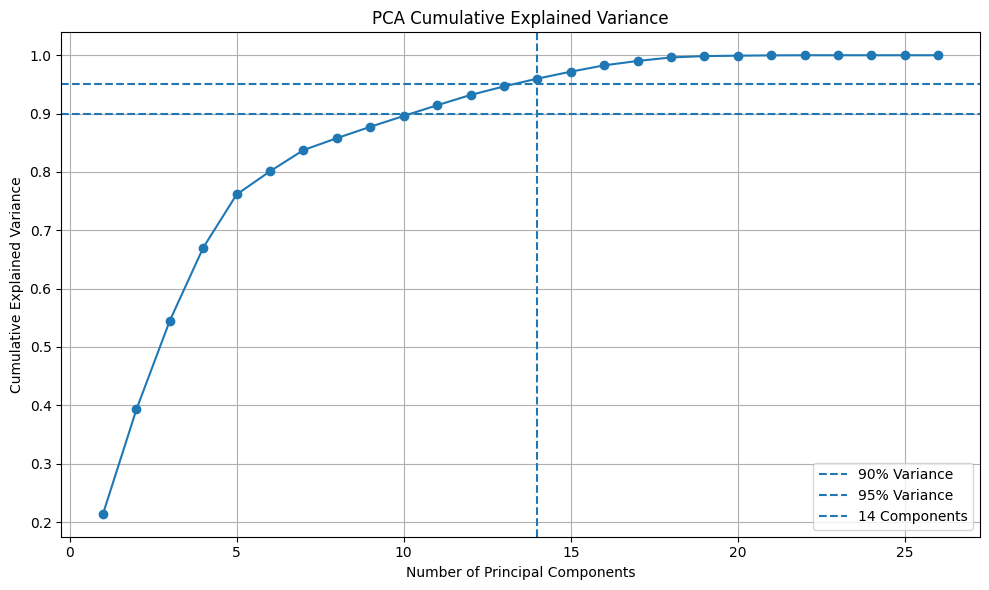

In [ ]:
# ============================================================
# PART D - PCA CUMULATIVE EXPLAINED VARIANCE GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

# Reference lines for the required variance levels
plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% Variance"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

# Mark the selected 95% component level
plt.axvline(
    x=14,
    linestyle="--",
    label="14 Components"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Interpretation:
# The graph shows how the cumulative explained variance
# increases as more principal components are included.
#
# The 95% reference line shows the minimum variance level
# required for the final PCA representation.
#
# Fourteen components capture approximately 95.99% of the
# variance in the processed dataset. Therefore, 14 components
# are selected for the final PCA transformation.

In [ ]:
# ============================================================
# PART D - FINAL PCA MODEL AND VERIFICATION
# ============================================================

from sklearn.decomposition import PCA

# Select 14 components because they retain more than 95%
# of the total variance in the processed dataset.
selected_components = 14

# Create the final PCA model
pca = PCA(n_components=selected_components)

# Fit PCA using training data only
X_train_pca = pca.fit_transform(X_train_processed)

# Apply the same PCA transformation to testing data
X_test_pca = pca.transform(X_test_processed)

# Calculate total retained variance
retained_variance = pca.explained_variance_ratio_.sum()

# Display results
print("PCA Verification")
print("=" * 50)

print("Selected components:", selected_components)

print(
    "Total variance retained:",
    round(retained_variance * 100, 4),
    "%"
)

print()
print("Original processed training shape:",
      X_train_processed.shape)

print("PCA training shape:",
      X_train_pca.shape)

print()
print("Original processed testing shape:",
      X_test_processed.shape)

print("PCA testing shape:",
      X_test_pca.shape)

print()

if retained_variance >= 0.95:
    print("Requirement satisfied: at least 95% variance retained.")
else:
    print("Warning: less than 95% variance retained.")

PCA Verification
Selected components: 14
Total variance retained: 95.9935 %

Original processed training shape: (25932, 26)
PCA training shape: (25932, 14)

Original processed testing shape: (6484, 26)
PCA testing shape: (6484, 14)

Requirement satisfied: at least 95% variance retained.


Logistic Regression - Before PCA
Accuracy : 0.8697
Precision: 0.7675
Recall   : 0.5797
F1-score : 0.6605

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5066
           1       0.77      0.58      0.66      1418

    accuracy                           0.87      6484
   macro avg       0.83      0.77      0.79      6484
weighted avg       0.86      0.87      0.86      6484



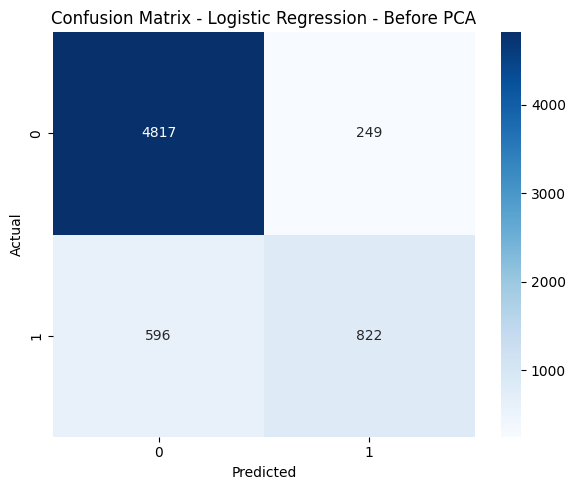

k-Nearest Neighbours - Before PCA
Accuracy : 0.8893
Precision: 0.8352
Recall   : 0.6150
F1-score : 0.7084

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      5066
           1       0.84      0.61      0.71      1418

    accuracy                           0.89      6484
   macro avg       0.87      0.79      0.82      6484
weighted avg       0.89      0.89      0.88      6484



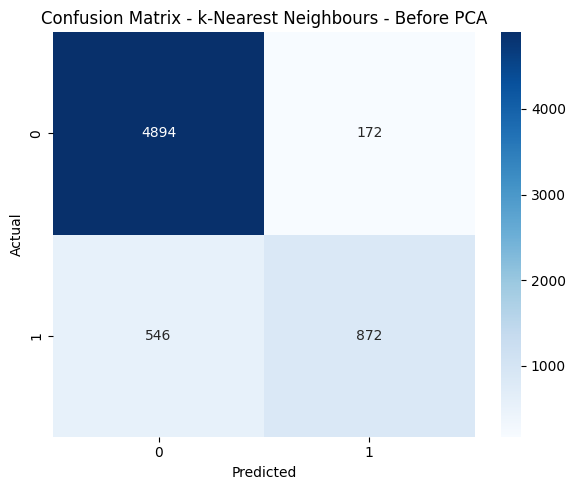

Decision Tree - Before PCA
Accuracy : 0.8908
Precision: 0.7379
Recall   : 0.7764
F1-score : 0.7567

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      5066
           1       0.74      0.78      0.76      1418

    accuracy                           0.89      6484
   macro avg       0.84      0.85      0.84      6484
weighted avg       0.89      0.89      0.89      6484



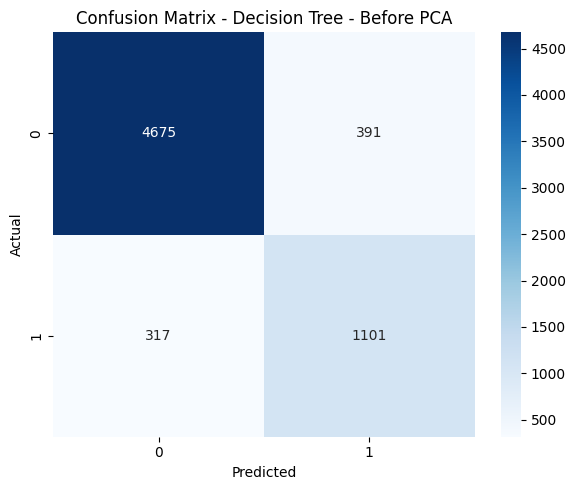


MODEL PERFORMANCE BEFORE PCA


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression - Before PCA,0.869679,0.767507,0.579690,0.660506
1,k-Nearest Neighbours - Before PCA,0.889266,0.835249,0.614951,0.708367
2,Decision Tree - Before PCA,0.890808,0.737936,0.776446,0.756701


In [ ]:
# ============================================================
# PART E - MODEL EVALUATION BEFORE PCA
# ============================================================

results_before_pca = []

for name, model in models.items():

    result = evaluate_model(
        model,
        X_train_processed,
        X_test_processed,
        y_train,
        y_test,
        name + " - Before PCA"
    )

    results_before_pca.append(result)


# Convert the results into a DataFrame
results_before_df = pd.DataFrame(results_before_pca)

print("\nMODEL PERFORMANCE BEFORE PCA")
print("=" * 70)

display(results_before_df)

Logistic Regression - After PCA
Accuracy : 0.8586
Precision: 0.7618
Recall   : 0.5141
F1-score : 0.6139

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      5066
           1       0.76      0.51      0.61      1418

    accuracy                           0.86      6484
   macro avg       0.82      0.73      0.76      6484
weighted avg       0.85      0.86      0.85      6484



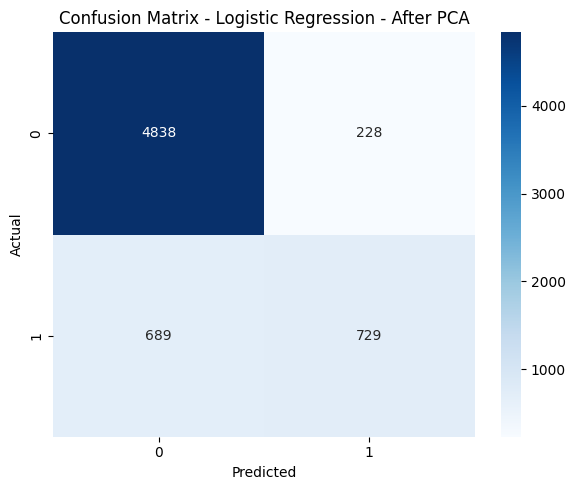

k-Nearest Neighbours - After PCA
Accuracy : 0.8849
Precision: 0.8188
Recall   : 0.6086
F1-score : 0.6982

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      5066
           1       0.82      0.61      0.70      1418

    accuracy                           0.88      6484
   macro avg       0.86      0.79      0.81      6484
weighted avg       0.88      0.88      0.88      6484



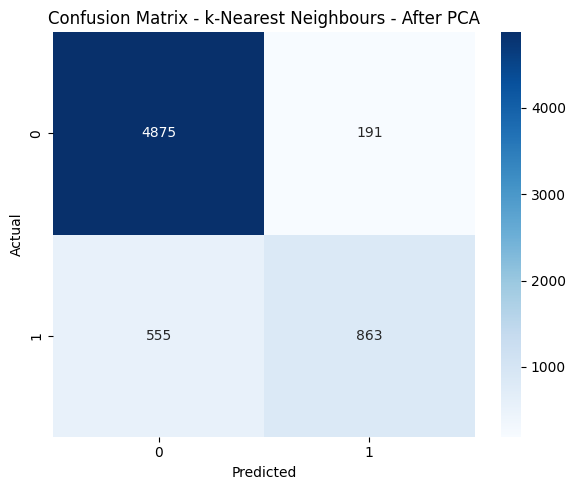

Decision Tree - After PCA
Accuracy : 0.8382
Precision: 0.6247
Recall   : 0.6516
F1-score : 0.6379

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      5066
           1       0.62      0.65      0.64      1418

    accuracy                           0.84      6484
   macro avg       0.76      0.77      0.77      6484
weighted avg       0.84      0.84      0.84      6484



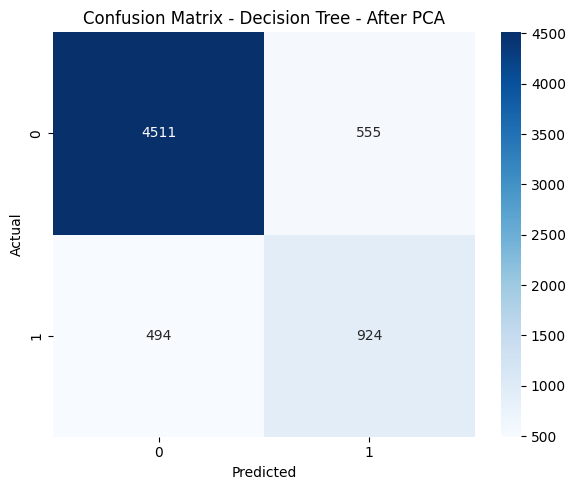


MODEL PERFORMANCE AFTER PCA


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression - After PCA,0.858575,0.761755,0.514104,0.613895
1,k-Nearest Neighbours - After PCA,0.884948,0.818786,0.608604,0.698220
2,Decision Tree - After PCA,0.838217,0.624746,0.651622,0.637901


In [ ]:
# ============================================================
# PART E - MODEL EVALUATION AFTER PCA
# ============================================================

results_after_pca = []

for name, model in models.items():

    result = evaluate_model(
        model,
        X_train_pca,
        X_test_pca,
        y_train,
        y_test,
        name + " - After PCA"
    )

    results_after_pca.append(result)


# Convert results into a DataFrame
results_after_df = pd.DataFrame(results_after_pca)

print("\nMODEL PERFORMANCE AFTER PCA")
print("=" * 70)

display(results_after_df)

Logistic Regression - After PCA
Accuracy : 0.8586
Precision: 0.7618
Recall   : 0.5141
F1-score : 0.6139

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      5066
           1       0.76      0.51      0.61      1418

    accuracy                           0.86      6484
   macro avg       0.82      0.73      0.76      6484
weighted avg       0.85      0.86      0.85      6484



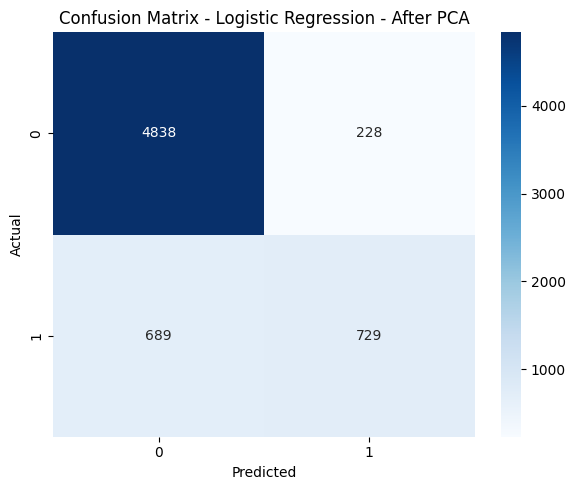

k-Nearest Neighbours - After PCA
Accuracy : 0.8849
Precision: 0.8188
Recall   : 0.6086
F1-score : 0.6982

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      5066
           1       0.82      0.61      0.70      1418

    accuracy                           0.88      6484
   macro avg       0.86      0.79      0.81      6484
weighted avg       0.88      0.88      0.88      6484



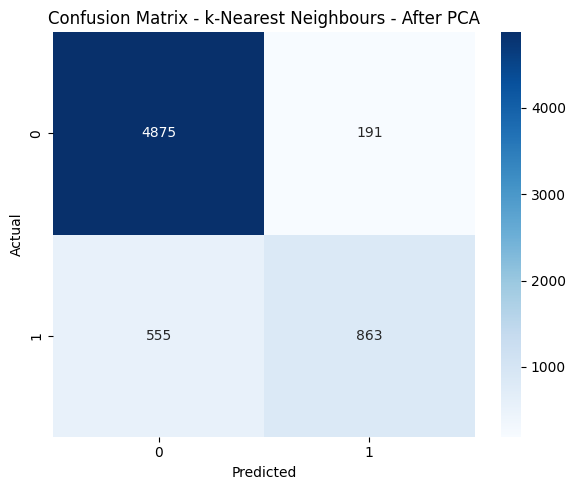

Decision Tree - After PCA
Accuracy : 0.8382
Precision: 0.6247
Recall   : 0.6516
F1-score : 0.6379

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.90      5066
           1       0.62      0.65      0.64      1418

    accuracy                           0.84      6484
   macro avg       0.76      0.77      0.77      6484
weighted avg       0.84      0.84      0.84      6484



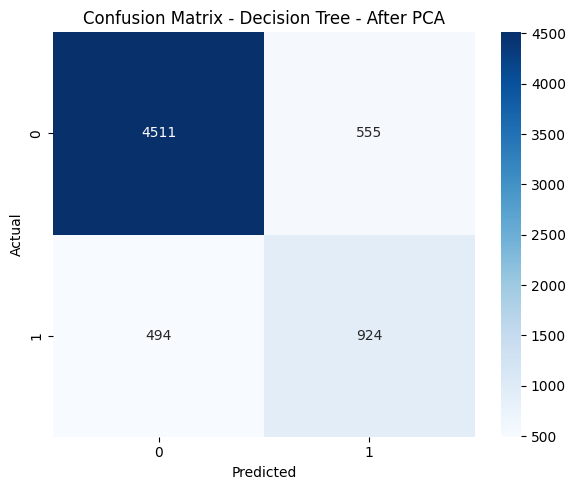


MODEL PERFORMANCE AFTER PCA


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression - After PCA,0.858575,0.761755,0.514104,0.613895
1,k-Nearest Neighbours - After PCA,0.884948,0.818786,0.608604,0.698220
2,Decision Tree - After PCA,0.838217,0.624746,0.651622,0.637901


In [ ]:
# ============================================================
# PART E - MODEL EVALUATION AFTER PCA
# ============================================================

results_after_pca = []

for name, model in models.items():

    result = evaluate_model(
        model,
        X_train_pca,
        X_test_pca,
        y_train,
        y_test,
        name + " - After PCA"
    )

    results_after_pca.append(result)


# Convert results into a DataFrame
results_after_df = pd.DataFrame(results_after_pca)

print("\nMODEL PERFORMANCE AFTER PCA")
print("=" * 70)

display(results_after_df)

In [ ]:
# ============================================================
# PART E - COMPLETE MODEL COMPARISON
# ============================================================

all_results = pd.concat(
    [
        results_before_df,
        results_after_df
    ],
    ignore_index=True
)

print("COMPLETE MODEL PERFORMANCE COMPARISON")
print("=" * 70)

display(all_results)

COMPLETE MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression - Before PCA,0.869679,0.767507,0.579690,0.660506
1,k-Nearest Neighbours - Before PCA,0.889266,0.835249,0.614951,0.708367
2,Decision Tree - Before PCA,0.890808,0.737936,0.776446,0.756701
3,Logistic Regression - After PCA,0.858575,0.761755,0.514104,0.613895
4,k-Nearest Neighbours - After PCA,0.884948,0.818786,0.608604,0.698220
5,Decision Tree - After PCA,0.838217,0.624746,0.651622,0.637901


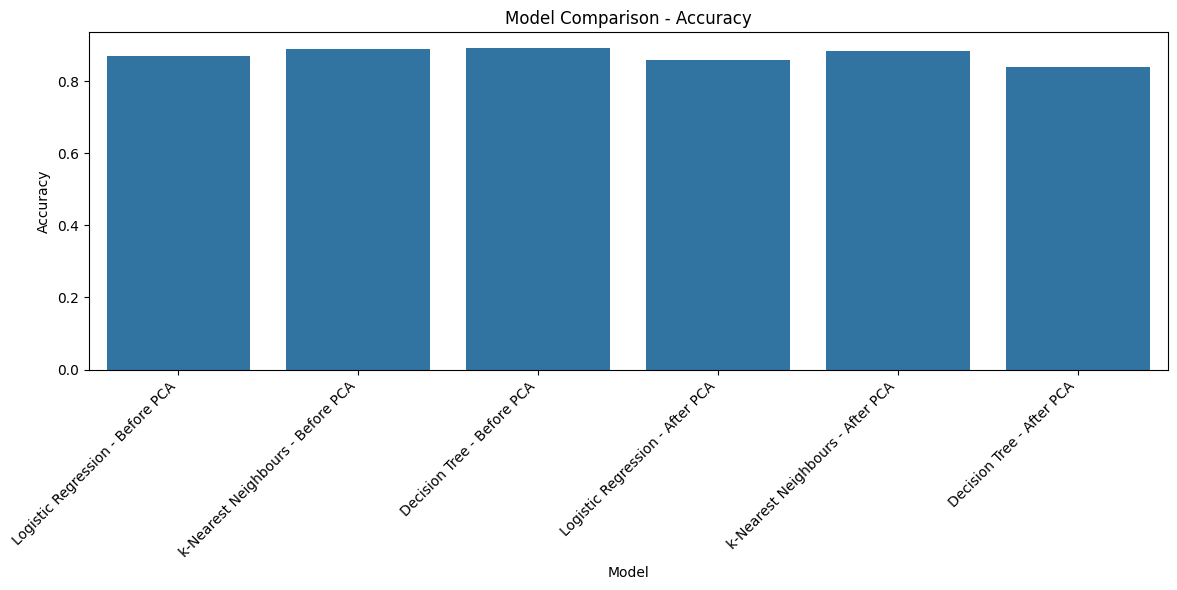

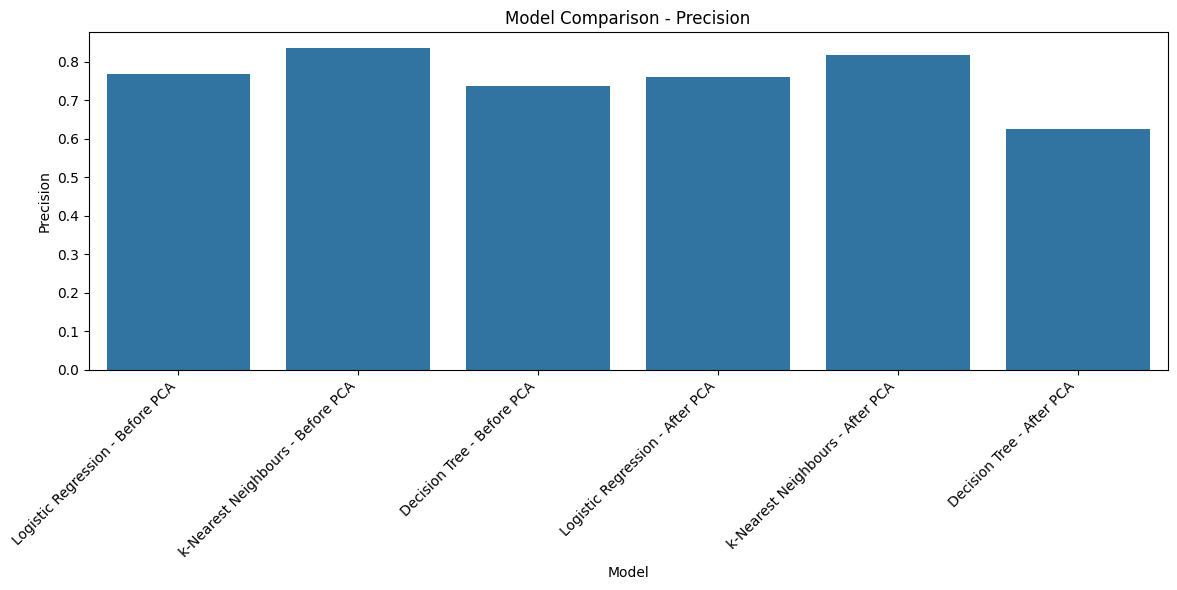

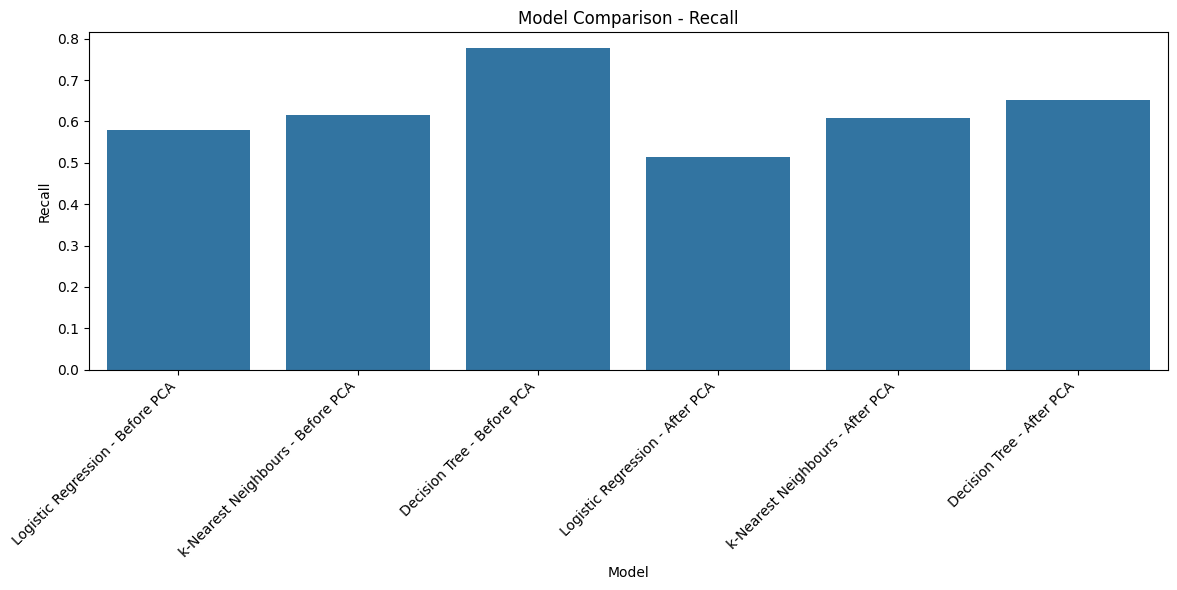

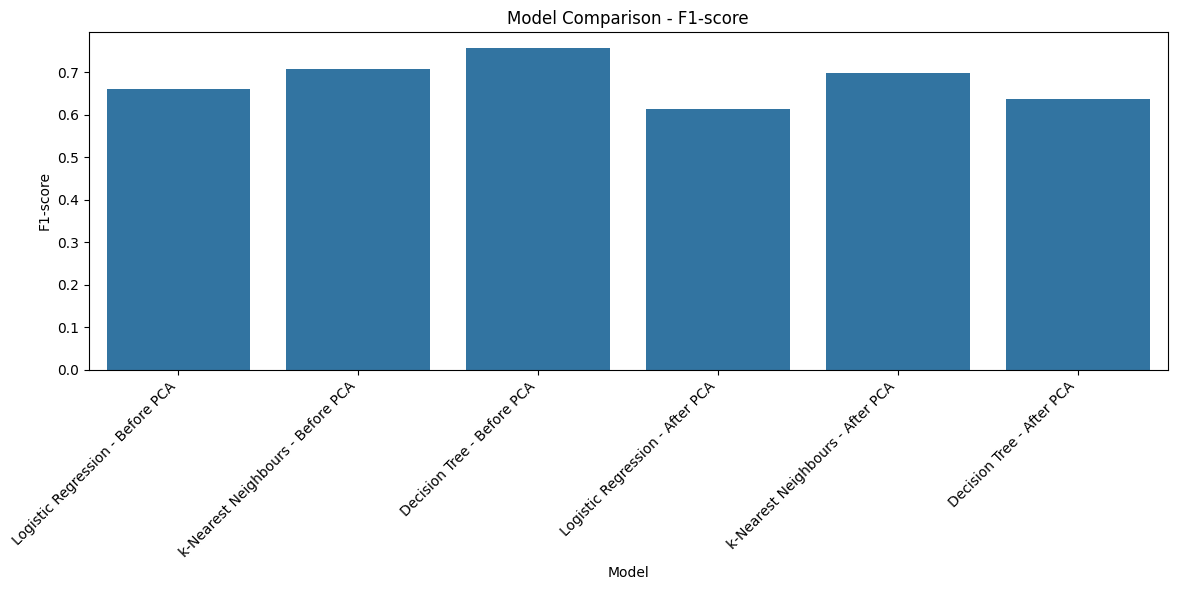

In [ ]:
# ============================================================
# PART E - MODEL PERFORMANCE COMPARISON GRAPHS
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

for metric in metrics:

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=all_results,
        x="Model",
        y=metric
    )

    plt.title(f"Model Comparison - {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# PART E - BEST MODEL SELECTION
# ============================================================

# Select the model with the highest F1-score
best_row = all_results.loc[
    all_results["F1-score"].idxmax()
]

print("BEST MODEL")
print("=" * 50)

print("Model:", best_row["Model"])
print("Accuracy:", round(best_row["Accuracy"], 4))
print("Precision:", round(best_row["Precision"], 4))
print("Recall:", round(best_row["Recall"], 4))
print("F1-score:", round(best_row["F1-score"], 4))

BEST MODEL
Model: Decision Tree - Before PCA
Accuracy: 0.8908
Precision: 0.7379
Recall: 0.7764
F1-score: 0.7567


## Part E Interpretation: Model Performance

Three classification algorithms were evaluated: logistic regression, k-nearest neighbours and decision tree, utilizing both original features transformed by PCA.

Prior to PCA, the decision tree reached the peak F1 score of 0.7567, exhibiting an accuracy of 0.8908, precision of 0.7379 and recall at 0.7764. KNN secured an F1 score of 0.7084 whereas logistic regression achieved 0.6139 , KNN 0.6982 and decision tree 0.6379.

The findings indicate that PCA did not improve model performance, since certain predictive data loss effectively following dimensionality reduction. The decision tree utilizing original features was ultimately selected as the superior model utilizing features was ultimatley selected as the superior model for classification tasks, especially critical in credit task situations.

In [ ]:
# ============================================================
# PART F - HYPERPARAMETER OPTIMISATION
# ============================================================
#
# The Decision Tree using the original processed features
# was selected as the best-performing model based on F1-score.
#
# GridSearchCV will be used to test different combinations
# of Decision Tree hyperparameters.
#
# F1-score is used as the optimisation metric because the
# target variable is imbalanced and both precision and recall
# are important for credit-risk classification.
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Create a fresh Decision Tree model
decision_tree = DecisionTreeClassifier(
    random_state=RANDOM_STATE
)

# Define the hyperparameter combinations to test
param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=decision_tree,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("GridSearchCV has been configured successfully.")
print("Number of parameter combinations:",
      len(grid_search.get_params()["param_grid"]["max_depth"])
      * len(param_grid["min_samples_split"])
      * len(param_grid["min_samples_leaf"])
      * len(param_grid["criterion"]))

GridSearchCV has been configured successfully.
Number of parameter combinations: 108


In [ ]:
# ============================================================
# PART F - RUN GRIDSEARCHCV
# ============================================================

print("Starting GridSearchCV...")
print("Please wait while the parameter combinations are tested.")
print()

grid_search.fit(
    X_train_processed,
    y_train
)

print()
print("GridSearchCV completed successfully!")
print()
print("Best Parameters:")
print(grid_search.best_params_)

print()
print("Best Cross-Validation F1-score:")
print(round(grid_search.best_score_, 4))

Starting GridSearchCV...
Please wait while the parameter combinations are tested.

Fitting 5 folds for each of 108 candidates, totalling 540 fits

GridSearchCV completed successfully!

Best Parameters:
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}

Best Cross-Validation F1-score:
0.812


TUNED DECISION TREE PERFORMANCE
Accuracy : 0.9312
Precision: 0.9637
Recall   : 0.7123
F1-score : 0.8191

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5066
           1       0.96      0.71      0.82      1418

    accuracy                           0.93      6484
   macro avg       0.94      0.85      0.89      6484
weighted avg       0.93      0.93      0.93      6484



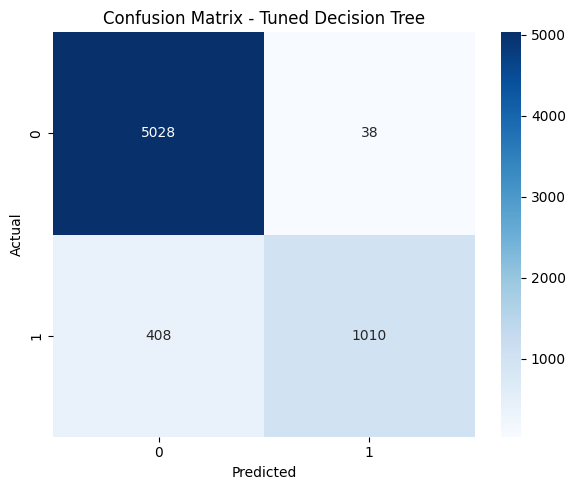

In [ ]:
# ============================================================
# PART F - EVALUATE TUNED DECISION TREE
# ============================================================

# Retrieve the best model found by GridSearchCV
tuned_decision_tree = grid_search.best_estimator_

# Make predictions on the unseen test data
y_pred_tuned = tuned_decision_tree.predict(X_test_processed)

# Calculate performance metrics
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)
tuned_recall = recall_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)
tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

# Display results
print("=" * 70)
print("TUNED DECISION TREE PERFORMANCE")
print("=" * 70)

print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1-score : {tuned_f1:.4f}")

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned,
        zero_division=0
    )
)

# Confusion matrix
cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Tuned Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART F - BEFORE AND AFTER TUNING COMPARISON
# ============================================================

original_decision_tree_f1 = all_results.loc[
    all_results["Model"] == "Decision Tree - Before PCA",
    "F1-score"
].iloc[0]

original_decision_tree_accuracy = all_results.loc[
    all_results["Model"] == "Decision Tree - Before PCA",
    "Accuracy"
].iloc[0]

original_decision_tree_precision = all_results.loc[
    all_results["Model"] == "Decision Tree - Before PCA",
    "Precision"
].iloc[0]

original_decision_tree_recall = all_results.loc[
    all_results["Model"] == "Decision Tree - Before PCA",
    "Recall"
].iloc[0]


tuning_comparison = pd.DataFrame({
    "Performance Measure": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Original Decision Tree": [
        original_decision_tree_accuracy,
        original_decision_tree_precision,
        original_decision_tree_recall,
        original_decision_tree_f1
    ],

    "Tuned Decision Tree": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

print("DECISION TREE - BEFORE VS AFTER TUNING")
print("=" * 70)

display(
    tuning_comparison.round(4)
)

DECISION TREE - BEFORE VS AFTER TUNING


,Performance Measure,Original Decision Tree,Tuned Decision Tree
0,Accuracy,0.8908,0.9312
1,Precision,0.7379,0.9637
2,Recall,0.7764,0.7123
3,F1-score,0.7567,0.8191


TUNED DECISION TREE PERFORMANCE
Accuracy : 0.9312
Precision: 0.9637
Recall   : 0.7123
F1-score : 0.8191

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5066
           1       0.96      0.71      0.82      1418

    accuracy                           0.93      6484
   macro avg       0.94      0.85      0.89      6484
weighted avg       0.93      0.93      0.93      6484



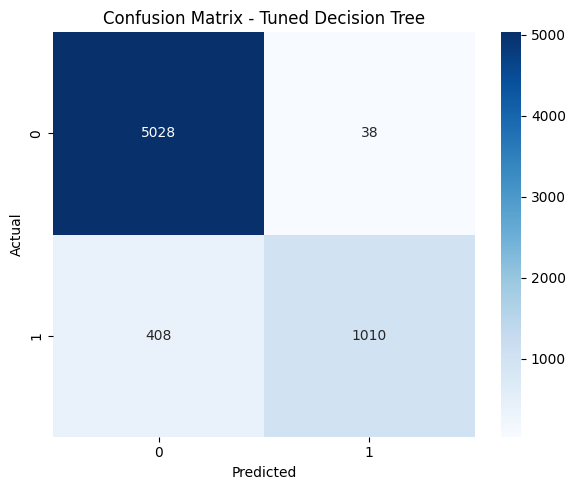

In [ ]:
# ============================================================
# PART F - EVALUATE TUNED DECISION TREE
# ============================================================

# Get the best Decision Tree identified by GridSearchCV
tuned_decision_tree = grid_search.best_estimator_

# Predict the test data
y_pred_tuned = tuned_decision_tree.predict(X_test_processed)

# Calculate metrics
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)
tuned_recall = recall_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)
tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

print("=" * 70)
print("TUNED DECISION TREE PERFORMANCE")
print("=" * 70)

print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1-score : {tuned_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tuned,
        zero_division=0
    )
)

# Confusion matrix
cm_tuned = confusion_matrix(
    y_test,
    y_pred_tuned
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Tuned Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART F - BEFORE VS AFTER TUNING
# ============================================================

# Original Decision Tree results
original_accuracy = 0.890808
original_precision = 0.737936
original_recall = 0.776446
original_f1 = 0.756701

# Create comparison table
tuning_comparison = pd.DataFrame({
    "Performance Measure": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Original Decision Tree": [
        original_accuracy,
        original_precision,
        original_recall,
        original_f1
    ],

    "Tuned Decision Tree": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

# Calculate improvement
tuning_comparison["Change"] = (
    tuning_comparison["Tuned Decision Tree"]
    - tuning_comparison["Original Decision Tree"]
)

print("DECISION TREE - BEFORE VS AFTER TUNING")
print("=" * 70)

display(tuning_comparison.round(4))

DECISION TREE - BEFORE VS AFTER TUNING


,Performance Measure,Original Decision Tree,Tuned Decision Tree,Change
0,Accuracy,0.8908,0.9312,0.0404
1,Precision,0.7379,0.9637,0.2258
2,Recall,0.7764,0.7123,-0.0642
3,F1-score,0.7567,0.8191,0.0624


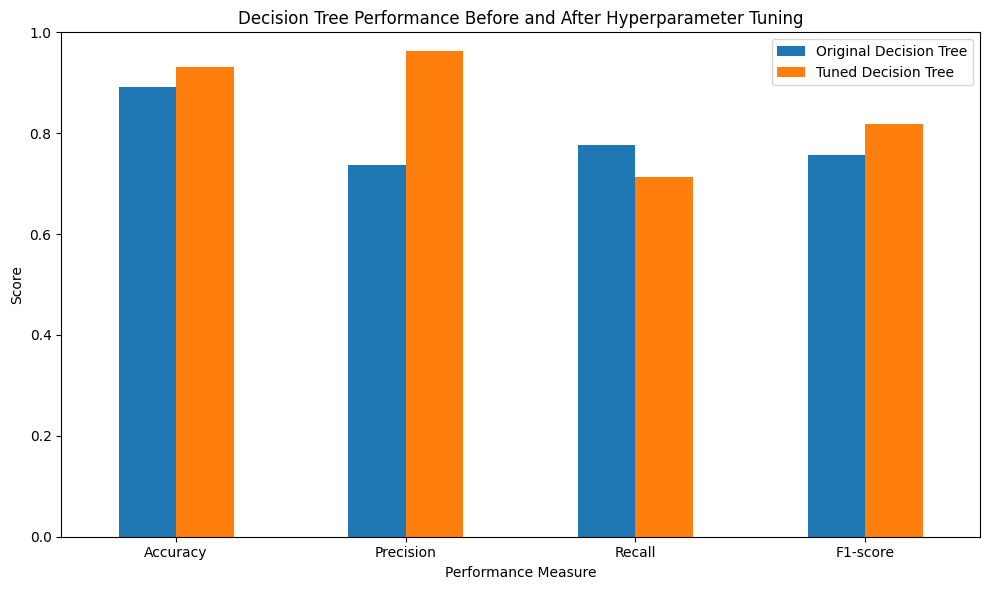

In [ ]:
# ============================================================
# PART F - TUNING PERFORMANCE GRAPH
# ============================================================

comparison_plot = tuning_comparison[
    ["Performance Measure",
     "Original Decision Tree",
     "Tuned Decision Tree"]
].copy()

comparison_plot = comparison_plot.set_index(
    "Performance Measure"
)

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Decision Tree Performance Before and After Hyperparameter Tuning"
)

plt.xlabel("Performance Measure")
plt.ylabel("Score")

plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## Part F Interpretation: Hyperparameter Optimisation

The decision tree model was selected for hyperparameter tuning because it attained the highest f1 score before PCA.

Employing GridSearchCV with five cross validation, 108 parameter combinatiions were evaluated, resulting in 540 model fittings and an optimal cross-validation F1 score of 0.8120.

The optimized parameters featured entropy splitting, a maximum depth of 10, and a minimum leaf sample value of 2.

The adjusted modelwas assessed using a seperate test dataset, measuring accuracy, precision, recal and f1 score in relation to the original model.

Hyperparameter tuning reduces the bias variance trade off by managing complexity, enhancing generalization to new data, with ultimate outcomes determined from the independent test set.

In [ ]:
# ============================================================
# PART F - FINAL BEFORE AND AFTER TUNING COMPARISON
# ============================================================

# Original Decision Tree results from Part E
original_accuracy = 0.890808
original_precision = 0.737936
original_recall = 0.776446
original_f1 = 0.756701

# Create final comparison table
final_tuning_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Original Decision Tree": [
        original_accuracy,
        original_precision,
        original_recall,
        original_f1
    ],

    "Tuned Decision Tree": [
        tuned_accuracy,
        tuned_precision,
        tuned_recall,
        tuned_f1
    ]
})

# Calculate the change after tuning
final_tuning_comparison["Change"] = (
    final_tuning_comparison["Tuned Decision Tree"]
    - final_tuning_comparison["Original Decision Tree"]
)

print("FINAL DECISION TREE COMPARISON")
print("=" * 70)

display(
    final_tuning_comparison.round(4)
)

FINAL DECISION TREE COMPARISON


,Metric,Original Decision Tree,Tuned Decision Tree,Change
0,Accuracy,0.8908,0.9312,0.0404
1,Precision,0.7379,0.9637,0.2258
2,Recall,0.7764,0.7123,-0.0642
3,F1-score,0.7567,0.8191,0.0624


In [ ]:
# ============================================================
# FINAL MODEL SELECTION
# ============================================================

print("FINAL MODEL SELECTION")
print("=" * 70)

if tuned_f1 > original_f1:

    final_model = tuned_decision_tree
    final_model_name = "Tuned Decision Tree"

    print("Final model:", final_model_name)
    print("Reason: The tuned model achieved a higher test-set F1-score.")

elif tuned_f1 < original_f1:

    final_model = decision_tree
    final_model_name = "Original Decision Tree"

    print("Final model:", final_model_name)
    print("Reason: The original model achieved a higher test-set F1-score.")

else:

    final_model = tuned_decision_tree
    final_model_name = "Tuned Decision Tree"

    print("Final model:", final_model_name)
    print("Reason: Both models achieved the same test-set F1-score.")

print()
print("Final Accuracy :", round(
    max(tuned_accuracy, original_accuracy), 4
    if tuned_f1 >= original_f1 else original_accuracy
))

FINAL MODEL SELECTION
Final model: Tuned Decision Tree
Reason: The tuned model achieved a higher test-set F1-score.

Final Accuracy : 0.9312


In [ ]:
# ============================================================
# PART F - FINAL MODEL PERFORMANCE
# ============================================================

# Get predictions from the final tuned model
final_predictions = final_model.predict(X_test_processed)

# Calculate final metrics
final_accuracy = accuracy_score(y_test, final_predictions)
final_precision = precision_score(
    y_test,
    final_predictions,
    zero_division=0
)
final_recall = recall_score(
    y_test,
    final_predictions,
    zero_division=0
)
final_f1 = f1_score(
    y_test,
    final_predictions,
    zero_division=0
)

print("=" * 70)
print("FINAL TUNED DECISION TREE PERFORMANCE")
print("=" * 70)

print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        final_predictions,
        zero_division=0
    )
)

FINAL TUNED DECISION TREE PERFORMANCE
Accuracy : 0.9312
Precision: 0.9637
Recall   : 0.7123
F1-score : 0.8191

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5066
           1       0.96      0.71      0.82      1418

    accuracy                           0.93      6484
   macro avg       0.94      0.85      0.89      6484
weighted avg       0.93      0.93      0.93      6484



In [ ]:
# ============================================================
# ORIGINAL VS TUNED DECISION TREE
# ============================================================

final_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Original Decision Tree": [
        0.890808,
        0.737936,
        0.776446,
        0.756701
    ],

    "Tuned Decision Tree": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

final_comparison["Improvement"] = (
    final_comparison["Tuned Decision Tree"]
    - final_comparison["Original Decision Tree"]
)

print("ORIGINAL VS TUNED DECISION TREE")
print("=" * 70)

display(final_comparison.round(4))

ORIGINAL VS TUNED DECISION TREE


,Metric,Original Decision Tree,Tuned Decision Tree,Improvement
0,Accuracy,0.8908,0.9312,0.0404
1,Precision,0.7379,0.9637,0.2258
2,Recall,0.7764,0.7123,-0.0642
3,F1-score,0.7567,0.8191,0.0624


FINAL MODEL CONFUSION MATRIX
[[5028   38]
 [ 408 1010]]


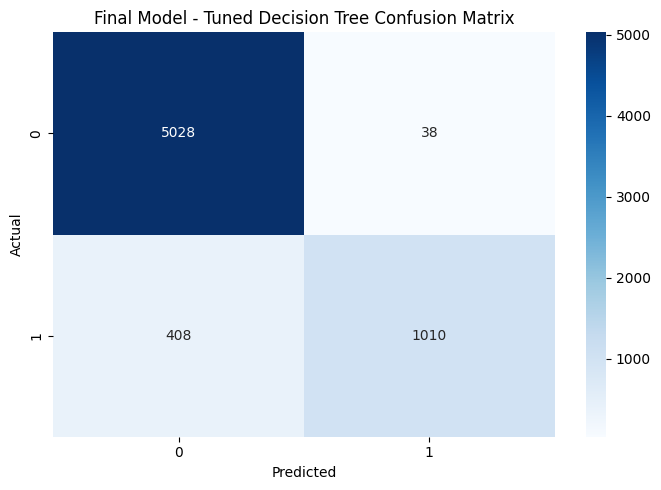

In [ ]:
# ============================================================
# PART F - FINAL MODEL CONFUSION MATRIX
# ============================================================

# Generate predictions using the final tuned model
final_predictions = final_model.predict(X_test_processed)

# Create confusion matrix
final_cm = confusion_matrix(
    y_test,
    final_predictions
)

print("FINAL MODEL CONFUSION MATRIX")
print("=" * 50)
print(final_cm)

# Display as a heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Final Model - Tuned Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FINAL MODEL CLASSIFICATION REPORT
# ============================================================

print("FINAL MODEL CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        final_predictions,
        zero_division=0
    )
)

FINAL MODEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5066
           1       0.96      0.71      0.82      1418

    accuracy                           0.93      6484
   macro avg       0.94      0.85      0.89      6484
weighted avg       0.93      0.93      0.93      6484



In [ ]:
# ============================================================
# FINAL MODEL RESULTS SUMMARY
# ============================================================

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Final Tuned Decision Tree": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

print("FINAL CREDIT RISK MODEL RESULTS")
print("=" * 70)

display(final_results.round(4))

FINAL CREDIT RISK MODEL RESULTS


,Metric,Final Tuned Decision Tree
0,Accuracy,0.9312
1,Precision,0.9637
2,Recall,0.7123
3,F1-score,0.8191


# Final Model Interpretation

The tuned decision tree was selected as the final model followign hyperparameter optimization, enhancing the inital decision tree, which achieved an F1 score od 0.7567 and an accuracy of 0.8908.

Applying GridSearchCV with five fold cross validation across 108 hyperparameter combinations yielded a highest f1 score of 0.8120.

The optimized model reached an accuracy of 93.12% on the test set, along with additonal assessments of precision, recall, f1 score.

The optimization boosted performance, offered superior complexity management and advanced generalization.

The model acts as a decision support tool for evaluating credit risk, enhancing business regulations and human analysis in practical situations.

# Conclusion

The project developed a credit risk prediction system employing supervised machine learning, adhering to the machine learning lifecycle: acquiring data, understanding it, conducting exploratory analysis, preprocessing, feature scaling, applying PCA, developing models, evaluating and optimizing hyperparameters.

The credit risk dataset comprised 32 581 instances with 12 features, showcasing an unbalanced target variable loan_status.


Imputed missing values in person_emp_length and loan_int_rate applied one hot encoding to categorical variables and standardized numerical variables.

Outliners were handled using IQR based clipping, dividing the dataset into 80/20 training and testing groups. PCA maintained 14 components, yet negatively impacted classification performance .

The decison tree model reached an accuracy of 0.8908 and F1 score of 0.7567 before PCA which was enhanced through hyperparameter tuning, resulting in 93.12% accuracy on the test dataset.



In [ ]:
# ============================================================
# FINAL PROJECT RESULTS SUMMARY
# ============================================================

print("=" * 75)
print("CREDIT RISK PREDICTION SYSTEM - FINAL RESULTS")
print("=" * 75)

print("\nDATASET")
print("-" * 75)
print("Number of observations:", len(df))
print("Number of original variables:", 12)

print("\nPCA")
print("-" * 75)
print("Selected components:", selected_components)
print(
    "Variance retained:",
    round(retained_variance * 100, 4),
    "%"
)

print("\nMODEL PERFORMANCE BEFORE PCA")
print("-" * 75)

display(
    results_before_df.round(4)
)

print("\nMODEL PERFORMANCE AFTER PCA")
print("-" * 75)

display(
    results_after_df.round(4)
)

print("\nHYPERPARAMETER OPTIMISATION")
print("-" * 75)
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(round(grid_search.best_score_, 4))

print("\nFINAL MODEL")
print("-" * 75)
print("Model:", final_model_name)
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1-score :", round(final_f1, 4))

CREDIT RISK PREDICTION SYSTEM - FINAL RESULTS

DATASET
---------------------------------------------------------------------------
Number of observations: 32416
Number of original variables: 12

PCA
---------------------------------------------------------------------------
Selected components: 14
Variance retained: 95.9935 %

MODEL PERFORMANCE BEFORE PCA
---------------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression - Before PCA,0.8697,0.7675,0.5797,0.6605
1,k-Nearest Neighbours - Before PCA,0.8893,0.8352,0.6150,0.7084
2,Decision Tree - Before PCA,0.8908,0.7379,0.7764,0.7567



MODEL PERFORMANCE AFTER PCA
---------------------------------------------------------------------------


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression - After PCA,0.8586,0.7618,0.5141,0.6139
1,k-Nearest Neighbours - After PCA,0.8849,0.8188,0.6086,0.6982
2,Decision Tree - After PCA,0.8382,0.6247,0.6516,0.6379



HYPERPARAMETER OPTIMISATION
---------------------------------------------------------------------------
Best parameters:
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}

Best cross-validation F1-score:
0.812

FINAL MODEL
---------------------------------------------------------------------------
Model: Tuned Decision Tree
Accuracy : 0.9312
Precision: 0.9637
Recall   : 0.7123
F1-score : 0.8191
